# Overview

In this notebook, we run _in silico_ experiments to ablate motifs, by neutralizing them in genomic sequences, and then examine the predicted accessibility in edited vs reference sequences. We will focus on negative motifs.

_Run on sherlock in the `tangermeme` environment._

# Setup

In [1]:
%load_ext autoreload
%autoreload

# deal with matplotlib plots
%matplotlib inline

# display all outputs in a cell
get_ipython().ast_node_interactivity = 'all'

from IPython.display import display, HTML

In [2]:
# misc
import sys
import os
import numpy as np
import random
from tqdm import tqdm
import pandas as pd

# io
import h5py
import pyfaidx
from pyfaidx import Fasta
import pyBigWig

# ML
import bpnetlite
from bpnetlite import ChromBPNet
from bpnetlite import BPNet
from bpnetlite.attribute import deep_lift_shap

import torch
import tangermeme
from tangermeme.io import extract_loci
from tangermeme.io import read_meme
from tangermeme.utils import random_one_hot
from tangermeme.utils import characters
from tangermeme.utils import one_hot_encode
from tangermeme.utils import reverse_complement
from tangermeme.utils import _validate_input
from tangermeme.space import space
from tangermeme.ersatz import multisubstitute
from tangermeme.ersatz import dinucleotide_shuffle
from tangermeme.marginalize import marginalize

from scipy.stats import wilcoxon, kstest
import scipy.signal

import pickle

# plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn; seaborn.set_style('white')
import matplotlib.ticker as ticker
from matplotlib.colors import to_hex
import plotnine as pn
import logomaker
from tangermeme.plot import plot_logo

print(f"numpy version: {np.__version__}")
print(f"tangermeme version: {tangermeme.__version__}")
print(f"bpnetlite version: {bpnetlite.__version__}")
print(f"torch version: {torch.__version__}")

torch.manual_seed(100)

# editable text in PDFs
# https://stackoverflow.com/a/54111532
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sys.path.append("../")
import tangermeme_utils as tanutils
from tangermeme_utils.constants import *
from tangermeme_utils.utils import plot_motif,get_rel_hit_positions,trim_cwm
from tangermeme_utils.wrappers import ChromBPNetWrapper, reshape_folds
from tangermeme_utils.eval import summarize_across_folds, mean_across_sequences

import chrombpnet_utils as cutils

/oak/stanford/groups/akundaje/sjessa/software/miniconda3/envs/tangermeme/lib/python3.12/site-packages/logomaker/__init__.py:46: SyntaxWarning: invalid escape sequence '\.'
/oak/stanford/groups/akundaje/sjessa/software/miniconda3/envs/tangermeme/lib/python3.12/site-packages/logomaker/src/validate.py:98: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/oak/stanford/groups/akundaje/sjessa/software/miniconda3/envs/tangermeme/lib/python3.12/site-packages/logomaker/src/validate.py:104: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?


numpy version: 1.26.4
tangermeme version: 0.4.3
bpnetlite version: 0.8.1
torch version: 2.2.2+cu121


/oak/stanford/groups/akundaje/sjessa/software/miniconda3/envs/tangermeme/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
/oak/stanford/groups/akundaje/sjessa/software/miniconda3/envs/tangermeme/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
/oak/stanford/groups/akundaje/sjessa/software/miniconda3/envs/tangermeme/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
/oak/stanford/groups/akundaje/sjessa/software/miniconda3/envs/tangermeme/lib/python3.12/site-packages/leidenalg/Optimiser.py:305: SyntaxWarning: invalid escape sequence '\s'


In [3]:
torch.cuda.device_count()

1

In [4]:
dev = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dev

torch.cuda.is_available()

t1 = torch.randn(1,2).to(dev)
t1
t1.device

device(type='cuda')

True

tensor([[ 0.3607, -0.2859]], device='cuda:0')

device(type='cuda', index=0)

In [5]:
from plotnine import (
	ggplot, aes, geom_boxplot, geom_point, geom_jitter, geom_density, geom_abline, theme, xlab, ylab, ggtitle, element_blank, element_text, element_rect, scale_fill_manual, scale_color_manual, coord_cartesian, geom_hline, facet_wrap, ylim, facet_grid
)

# Variables

# Paths

In [6]:
with open("../../ROOT_DIR.txt", 'r') as f:
    proj_dir = f.readline().strip()

with open("../../AK_PROJ_DIR.txt", 'r') as f:
    kundaje_dir = f.readline().strip()

In [7]:
# input paths
chrombpnet_dir = os.path.join(proj_dir, "output/03-chrombpnet")
contribs_dir = os.path.join(chrombpnet_dir, "01-models/contribs/bias_Heart_c0_thresh0.4")

# output paths
figout = os.path.join(proj_dir, "figures/03-chrombpnet/03-syntax/06")
os.makedirs(figout, exist_ok=True)

out = os.path.join(proj_dir, "output/03-chrombpnet/03-syntax/06")
os.makedirs(out, exist_ok=True)

In [8]:
# load genome
genome_fa = os.path.join(kundaje_dir, "refs/hg38/chrombpnet/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta")
hg38 = pyfaidx.Fasta(genome_fa)

In [9]:
# load annotated motifs
motif_annotations = pd.read_csv(os.path.join(chrombpnet_dir, "03-syntax/01/motifs_compiled_unique.tsv"), sep = "\t")
motif_annotations[["idx_uniq", "motif_name", "pattern", "annotation", "category"]]

# get first 5 rows 
display(HTML(motif_annotations[:5].to_html()))

,idx_uniq,motif_name,pattern,annotation,category
0,0,0|AP-2,pos.Average_272__merged_pattern_1,AP-2,base
1,100,100|BZIP:ATF/CREB#2,pos.Average_280__merged_pattern_37,BZIP:ATF/CREB#2,base_with_flank
2,101,101|BZIP:ATF/CREB#3,pos.Average_306__merged_pattern_77,BZIP:ATF/CREB#3,base_with_flank
3,102,102|BZIP:ATF/CREB#4,pos.Average_116__merged_pattern_0,BZIP:ATF/CREB#4,base_with_flank
4,103,103|BZIP:ATF/CREB#5,pos.Average_85__merged_pattern_6,BZIP:ATF/CREB#5,base_with_flank
...,...,...,...,...,...
503,96,96|BHLH_ZEB/SNAI_ZEB/SNAI,neg.Average_12__merged_pattern_6,BHLH_ZEB/SNAI_ZEB/SNAI,heterocomposite
504,97,97|BHLH_p53,pos.Average_229__merged_pattern_4,BHLH_p53,heterocomposite
505,98,98|BHLHpartial,pos.Average_303__merged_pattern_13,BHLHpartial,partial
506,99,99|BZIP:ATF/CREB#1,pos.Average_280__merged_pattern_0,BZIP:ATF/CREB#1,base


,motif_name,total_hits,idx,idx_uniq,pattern_class,pattern,total_n_seqlets,n_component_patterns,n_component_celltypes,n_component_organs,component_organs,component_celltypes,modisco_cwm_fwd,modisco_cwm_rev,query_consensus,annotation,annotation_broad,annotation_syntax,verified_SJ,category,composite_more_than_two,nucleotide_importance,revcomp,match_to_known_motif,note,cwm_entropy,entropy_ratio,pair_entropy_ratio,dinuc_entropy_ratio,TF0,motif0,qval0,match0_logo,match0_TFs_in_family,match0_TFs_in_archetype,match0_jolma,qval0_jolma,match0_logo_jolma,match1,qval1,match1_logo,match2,qval2,match2_logo,top_organ,motif_name_safe
0,0|AP-2,324445,182,0,pos_patterns,pos.Average_272__merged_pattern_1,12769,6,6,2,"Eye,Skin","horizontal,amacrine,melanocyte,interfollicular cells,epidermal progenitor,keratinocyte",/oak/stanford/groups/wjg/skim/projects/HDMA-public/output/03-chrombpnet/02-compendium/modisco_compiled/trimmed_logos/pos_patterns.pos.Average_272__merged_pattern_1.cwm.fwd.png,/oak/stanford/groups/wjg/skim/projects/HDMA-public/output/03-chrombpnet/02-compendium/modisco_compiled/trimmed_logos/pos_patterns.pos.Average_272__merged_pattern_1.cwm.rev.png,CCCTGAGGC,AP-2,AP-2,NaN,Y,base,NaN,pos,NaN,NaN,NaN,0.633785,1.481282,1.711649,1.638694,TFAP2C,M07783_2.00,7.630000e-07,NaN,"TFAP2A,TFAP2B,TFAP2C,TFAP2E","AC0043: TFAP2A,TFAP2B,TFAP2C,TFAP2E",ETS_PAX|ELK1_PAX1,0.999999,NaN,TFAP2A: M07784_2.00,7.630000e-07,NaN,TFAP2A: MA0003.2,0.000002,NaN,Skin,0.AP-2
1,100|BZIP:ATF/CREB#2,32455,326,100,pos_patterns,pos.Average_280__merged_pattern_37,45,1,1,1,Heart,epicardial,/oak/stanford/groups/wjg/skim/projects/HDMA-public/output/03-chrombpnet/02-compendium/modisco_compiled/trimmed_logos/pos_patterns.pos.Average_280__merged_pattern_37.cwm.fwd.png,/oak/stanford/groups/wjg/skim/projects/HDMA-public/output/03-chrombpnet/02-compendium/modisco_compiled/trimmed_logos/pos_patterns.pos.Average_280__merged_pattern_37.cwm.rev.png,TGATGTCATCAC,BZIP:ATF/CREB#2,BZIP,NaN,Y,base_with_flank,NaN,pos,Y,NaN,overlapping sites?,0.641649,1.324774,1.515424,1.474011,ATF3,M04324_2.00,2.947000e-02,NaN,"ATF3,JDP2","AC0547: ATF1,ATF2,ATF3,ATF4,ATF6,ATF6B,ATF7,BACH2,BATF3,CREB1,CREB3,CREB3L4,CREB5,CREM,FOS,FOS::JUN,FOSB,FOSB::JUN,FOSB::JUNB,FOSL1,FOSL1::JUN,FOSL1::JUND,FOSL2,FOSL2::JUN,FOSL2::JUNB,FOSL2::JUND,JDP2,JUN,JUN::JUNB,JUNB,JUND,XBP1,ZNF614",bZIP_bZIP|ATF4_TEF,0.796533,NaN,JUND: M09487_2.00,2.947000e-02,NaN,BATF3: M02833_2.00,0.029470,NaN,Heart,100.BZIP:ATF.CREB#2
2,101|BZIP:ATF/CREB#3,16072,690,101,pos_patterns,pos.Average_306__merged_pattern_77,51,1,1,1,Skin,fibroblast,/oak/stanford/groups/wjg/skim/projects/HDMA-public/output/03-chrombpnet/02-compendium/modisco_compiled/trimmed_logos/pos_patterns.pos.Average_306__merged_pattern_77.cwm.fwd.png,/oak/stanford/groups/wjg/skim/projects/HDMA-public/output/03-chrombpnet/02-compendium/modisco_compiled/trimmed_logos/pos_patterns.pos.Average_306__merged_pattern_77.cwm.rev.png,TGAGGTCATTTCC,BZIP:ATF/CREB#3,BZIP,NaN,Y,base_with_flank,NaN,pos,NaN,NaN,like #723,0.632000,1.370000,1.570000,1.490000,ZNF200,M08232_2.00,2.857700e-01,NaN,not found in HOCOMOCO,"AC0622: EHF,ELF1,ELF2,ELF3,ELF4,ELF5,ETS2,ETV4,ETV5,FEV,FLI1,RUNX1,SPI1,SPIB,SPIC,ZNF200",ETS_bZIP|ELK1_TEF,0.020300,NaN,JUN: M07836_2.00,2.857700e-01,NaN,ZNF528: M08328_2.00,0.286000,NaN,Skin,101.BZIP:ATF.CREB#3
3,102|BZIP:ATF/CREB#4,5680,3,102,pos_patterns,pos.Average_116__merged_pattern_0,47,2,2,2,"Muscle,Skin","smooth muscle,keratinocyte",/oak/stanford/groups/wjg/skim/projects/HDMA-public/output/03-chrombpnet/02-compendium/modisco_compiled/trimmed_logos/pos_patterns.pos.Average_116__merged_pattern_0.cwm.fwd.png,/oak/stanford/groups/wjg/skim/projects/HDMA-public/output/03-chrombpnet/02-compendium/modisco_compiled/trimmed_logos/pos_patterns.pos.Average_116__merged_pattern_0.cwm.rev.png,CGGTGACATCACGGATAGGGCG,BZIP:ATF/CREB#4,BZIP,NaN,Y,base_with_flank,NaN,pos,Y,NaN,NaN,0.590911,1.291178,1.561602,1.512331,CREB1,M04262_2.00,4.763320e-02,NaN,"ATF1,CREB1,CREM","AC0547: ATF1,ATF2,ATF3,ATF4,A

In [10]:
motif_annotations[motif_annotations['pattern_class'] == 'neg_patterns']

,motif_name,total_hits,idx,idx_uniq,pattern_class,pattern,total_n_seqlets,n_component_patterns,n_component_celltypes,n_component_organs,...,qval0_jolma,match0_logo_jolma,match1,qval1,match1_logo,match2,qval2,match2_logo,top_organ,motif_name_safe
259,333|HIC,1844411,827,333,neg_patterns,neg.Heart__Heart_c3__neg_patterns.pattern_1__merged_pattern_0,54,1,1,1,...,0.998926,NaN,HIC1: M04569_2.00,0.220771,NaN,HIC2: M02902_2.00,0.465215,NaN,Heart,333.HIC
302,372|NFYrepressive,503554,821,372,neg_patterns,neg.Average_14__merged_pattern_0,577,14,14,7,...,0.260956,NaN,NFYB: MA0502.1,0.022362,NaN,NFYA: MA0060.2,0.089179,NaN,Heart,372.NFYrepressive
394,455|YY1/2repressive,1297761,822,455,neg_patterns,neg.Average_15__merged_pattern_0,96,3,3,1,...,0.573931,NaN,THAP1: M08020_2.00,0.020886,NaN,YY1: M08865_2.00,0.020886,NaN,Lung,455.YY1.2repressive
395,456|ZEB/SNAI,34011538,806,456,neg_patterns,neg.Average_12__merged_pattern_0,11559,50,43,8,...,0.999935,NaN,ZEB1: MA0103.2,0.125794,NaN,ZEB1: M10093_2.00,0.125794,NaN,Skin,456.ZEB.SNAI
396,457|ZEB/SNAI_ZEB/SNAI#1,34797,810,457,neg_patterns,neg.Average_12__merged_pattern_12,25,1,1,1,...,0.298195,NaN,SNAI1: M08886_2.00,0.281113,NaN,TCF12: M07806_2.00,0.281113,NaN,Skin,457.ZEB.SNAI_ZEB.SNAI#1
397,458|ZEB/SNAI_ZEB/SNAI#2,77275,813,458,neg_patterns,neg.Average_12__merged_pattern_2,176,6,6,5,...,0.139536,NaN,SNAI1: M08886_2.00,0.111005,NaN,TCF4: M04214_2.00,0.111005,NaN,Heart,458.ZEB.SNAI_ZEB.SNAI#2
398,459|ZEB/SNAI_ZEB/SNAI#3,30240,815,459,neg_patterns,neg.Average_12__merged_pattern_4,57,2,2,2,...,0.380871,NaN,TCF12: M07806_2.00,0.275712,NaN,TCF4: M02728_2.00,0.852897,NaN,Skin,459.ZEB.SNAI_ZEB.SNAI#3
400,460|ZEB/SNAI_ZEB/SNAI#4,120802,814,460,neg_patterns,neg.Average_12__merged_pattern_3,95,3,3,3,...,0.786235,NaN,ASCL1: MA1631.1,0.515614,NaN,ASCL1: M08730_2.00,0.515614,NaN,Lung,460.ZEB.SNAI_ZEB.SNAI#4
401,461|ZEB/SNAI_ZEB/SNAI#5,118559,819,461,neg_patterns,neg.Average_12__merged_pattern_8,31,1,1,1,...,0.009807,NaN,ZNF784: M02918_2.00,0.074639,NaN,ZNF784: M04588_2.00,0.463831,NaN,Muscle,461.ZEB.SNAI_ZEB.SNAI#5
443,4|BCL11A/Brepressive,5056133,832,4,neg_patterns,neg.Thymus__Average_6__merged_pattern_0,192,3,3,1,...,1.000000,NaN,REST: M09501_2.00,1.000000,NaN,ZNF296: M04544_2.00,1.000000,NaN,Thymus,4.BCL11A.Brepressive


In [11]:
# helper function to get the motif name
def get_motif_name(motif_id):
	"""
	Get the motif name (with unique index) for a given motif, using its MoDISco pattern name '<pattern_class>.pattern_<X>'.
	"""
	return motif_annotations[motif_annotations["pattern"] == motif_id]['motif_name'].values[0]

def get_pattern_name(motif_name):
	"""
	Get the motif pattern name for a given motif, using it's HDMA index '<idx>|<annotation>'.
	"""
	return motif_annotations[motif_annotations["motif_name"] == motif_name]['pattern'].values[0]

# Example usage
get_motif_name("pos.Average_286__merged_pattern_6")

'144|BZIP:FOSL/JUND_TEAD'

In [12]:
# load compiled modisco object, containing merged motifs
compiled_modisco_h5_path = os.path.join(chrombpnet_dir, "02-compendium/modisco_compiled/modisco_compiled.h5")
modisco_obj = h5py.File(compiled_modisco_h5_path)

# Helper functions

## Model loading

In [13]:
def load_5f_models(cluster, wrapper = tanutils.wrappers.ChromBPNetWrapper, mode = "corrected"):
	"""
	Helper function to load five-fold BPNet models for the given HDMA cluster from the specified directory.

	Returns
	-------
	list of wrapped BPNet models
		List containing five wrapped BPNet models.
	"""

	if mode == "corrected":
		
		return [
			wrapper(
				BPNet.from_chrombpnet(
					filename=os.path.join(
						chrombpnet_dir,
						f"01-models/models/bias_Heart_c0_thresh0.4/{cluster}/fold_{i}/models/chrombpnet_nobias.h5"
					)
				)
			)
			for i in range(5)
		]

	elif mode == "uncorrected":

		return [
			wrapper(
				ChromBPNet.from_chrombpnet(
					bias_model = os.path.join(
						chrombpnet_dir,
						f"01-models/models/bias_Heart_c0_thresh0.4/{cluster}/fold_{i}/models/bias_model_scaled.h5"
					),
					accessibility_model = os.path.join(
						chrombpnet_dir,
						f"01-models/models/bias_Heart_c0_thresh0.4/{cluster}/fold_{i}/models/chrombpnet_nobias.h5"
					),
					name = "ChromBPNet"
				)
			)
			for i in range(5)
		]

## Getting and plotting insertion counts at hits

In [14]:
def extract_accessibility(hits, obs_bw_path, revcomp = True, revcomp_strand = '-', central_window = 500):

    width = central_window

    obs_insertions = []

    obs_bigwig = pyBigWig.open(obs_bw_path  )

    for idx, row in hits.iterrows():

        hit_width = row['end'] - row['start']

        # if reverse complementing, then if the hit_width is odd length, bump
        # center so that the nucleotides in the actual hit will be aligned
        # after the reverse complementing
        if hit_width % 2 == 1 and row['strand'] == revcomp_strand:
            center = 1 + row['start'] + hit_width//2
        else:
            center = row['start'] + hit_width//2

        # coordinates of region to extract
        # check if the chromosome key is seqnames or chr
        if 'seqnames' in row:
            region_chr = row['seqnames']
        else:
            region_chr = row['chr']

        region_start = (center - width//2)
        region_end = (center + width//2)

        # get accesibility
        ins = cutils.io.extract_from_bw(obs_bigwig, region_chr, region_start, region_end)

        # reverse complement the observed accessibility, if a hit is on the
        # strand to rev-comp
        if revcomp and row['strand'] == revcomp_strand:
            
            ins = ins[::-1]
            
        obs_insertions.append(ins)

    # close the bigwig file
    obs_bigwig.close()

    return obs_insertions

In [15]:
def normalize_row(row, range = [0, 1]):
    """
    Normalize the row to the range [0, 1] or [-1, 1].
    """

    if (range == [0, 1]):

        pseudocount = 1e-8
    
        min_val = np.min(row)
        max_val = np.max(row)
    
        return (row - min_val) / (pseudocount + max_val - min_val)

    elif (range == [-1, 1]):
        
        max_val = np.max(np.abs(row))
        return row / max_val


def hit_insertions_heatmap(obs_insertions, pattern_name=None, figsize=(10, 6), hit_order=None, central_window=None, fix_y_max = True, normalize = True):
    """
    Plot a heatmap showing ATACseq insertions at each sequence, for a set of aligned hits.
    """

    from plotnine import (
        ggplot,
        aes,
        geom_tile,
        geom_text,
        geom_boxplot,
        scale_y_reverse,
        scale_y_discrete,
        scale_fill_cmap,
        scale_fill_brewer,
        scale_fill_manual,
        scale_alpha_continuous,
        scale_fill_gradient2,
        scale_fill_cmap,
        scale_x_discrete,
        coord_equal,
        coord_cartesian,
        theme,
        theme_void,
        theme_minimal,
        element_blank,
        element_rect,
        element_text,
        xlab,
        ylab,
        labs,
        ggtitle
    )

    from matplotlib.colors import to_hex
    
    # get order
    if hit_order is not None:
        obs_insertions = [obs_insertions[i] for i in hit_order]

    obs_insertions = np.array(obs_insertions)

    # trim if needed
    if central_window is not None and central_window < obs_insertions.shape[1]:
        start = obs_insertions.shape[1] // 2 - central_window // 2
        obs_insertions = obs_insertions[:, start:start + central_window]
    else:
        central_window = obs_insertions.shape[0]

    # log10
    log_scores = np.log10(obs_insertions + 1)

    if normalize:
        normalized_scores = np.apply_along_axis(normalize_row, 1, log_scores, range = [-1, 1])
    else:
        normalized_scores = log_scores
    
    # convert the list of arrays to a DataFrame for visualization
    score_df = pd.DataFrame(normalized_scores)

    n_hits = len(obs_insertions)

    # convert to long format
    score_df_long = pd.melt(score_df.reset_index(), id_vars = "index", var_name = "position", value_name = "score")
    score_df_long = score_df_long.rename(columns={'index': 'hit'})

    # get color limits
    if fix_y_max:
        y_max = 2.5
    else:
        y_max = score_df_long['score'].max()

    p = (
        ggplot(score_df_long, aes("position", "hit"))
        + geom_tile(aes(fill="score"))
        + labs(fill="log10(insertions)") + ggtitle(f"{pattern_name} \nhits insertions")
    )
    
    # more aesthetic adjustments
    p = (p
        # + scale_fill_gradient2(low="blue", mid="white", high="navy", midpoint=0, limits = [0, 2.5])
        + scale_fill_cmap(limits=[0, y_max])
        + theme( 
            axis_ticks=element_blank(),
            axis_text_x=element_text(size = 6),
            panel_background=element_rect(fill="white"),
            figure_size=figsize
        )
        # guides(fill=guide_colorbar(ticks.colour = NA)) +
        + xlab("position (bp)") + ylab(f"hits (n={n_hits})")
    )

    if central_window > 20:

        tick_step = central_window // 4
        ticks = list(range(0, central_window + 1, tick_step))
        labels = [str(x - (central_window // 2)) for x in ticks]
        ticks[4] = ticks[4] - 1  # adjust last tick to be within bounds

        p = (
            p + scale_x_discrete(breaks=ticks, labels=labels)
              + theme(axis_text_x=element_text(size = 10))
        )

    return p

## Plot observed footprint

The way BPCells does it is to normalize by the average at the distant local regions,
by default the outer 10% of the flanks:

https://github.com/bnprks/BPCells/blob/b7272b713b2bf9cd610d64a2b8d5588cd44a0964/r/R/atac_utils.R#L129

```r
if (normalization_width > 0) {
    flank_indices <- c(seq_len(normalization_width), ncol(mat) + 1 - seq_len(normalization_width))
    mat_norm <- mat / rowMeans(mat[, flank_indices, drop = FALSE])
  } else {
    mat_norm <- NA
  }
```

In [16]:
def plot_footprint(obs, title, normalize = False):

	# stack observations into one tensor
	obs_tensor = np.stack(obs)
	obs_tensor.shape

	# get colsums
	obs_col_sums = np.sum(obs_tensor, axis=0)

	# define normalization width
	width = obs_col_sums.shape[0]
	flank = width // 2
	normalization_width = flank // 10
	normalization_width

	if normalize:
		# get the indices for the flanking regions
		flank_indices = list(range(normalization_width)) + list(range(len(obs_col_sums) - normalization_width, len(obs_col_sums)))
		print(len(flank_indices))

		# normalize the footprint values by the mean of the flanking regions
		flank_means = np.mean(obs_col_sums[flank_indices])
		obs_norm = obs_col_sums / flank_means
		y_axis = "Normalized insertions (enrichment)"

	else:
		obs_norm = obs_col_sums
		y_axis = "Total insertions"

	plt.figure(figsize=(4, 4))
	plt.plot(obs_norm, color="navy", alpha = 0.8, lw = 0.5)
	plt.title(f"{title}\nobserved ATACseq footprint")
	plt.xlabel("Genomic position (bp)")
	plt.ylabel(y_axis)

	# automatically compute ticks given the window
	tick_step = width // 4
	ticks = list(range(0, width + 1, tick_step))
	labels = [str(x - (width // 2)) for x in ticks]
	plt.xticks(ticks=ticks, labels=labels)

	plt.show();

In [17]:
def plot_footprint2(obs, title, normalize = False, split_by_quantile = False):

    from plotnine import (
		ggplot, aes, geom_line, labs, theme_minimal, scale_x_continuous, ggtitle, element_text
	)

    # stack observations into one tensor
    obs_tensor = np.stack(obs)
    obs_tensor.shape

    # get colsums
    obs_col_sums = np.sum(obs_tensor, axis=0)

    # define normalization width
    width = obs_col_sums.shape[0]
    flank = width // 2
    normalization_width = flank // 10
    normalization_width

    if normalize:
        # get the indices for the flanking regions
        flank_indices = list(range(normalization_width)) + list(range(len(obs_col_sums) - normalization_width, len(obs_col_sums)))
        print(len(flank_indices))

        # normalize the footprint values by the mean of the flanking regions
        flank_means = np.mean(obs_col_sums[flank_indices])
        obs_norm = obs_col_sums / flank_means
        y_axis = "Normalized insertions (enrichment)"

    else:
        obs_norm = obs_col_sums
        y_axis = "Total insertions"

    # Prepare data for plotnine
    data = pd.DataFrame({
        "Position": range(-flank, flank),
        "Insertions": obs_norm
    })

    # Automatically compute ticks given the window
    num_ticks = 5
    tick_step = max(1, width // (num_ticks - 1))
    ticks = list(range(0, width + 1, tick_step))
    labels = [str(x - flank) for x in ticks]

    # create the plot using plotnine
    p = (
        ggplot(data, aes(x="Position", y="Insertions"))
        + geom_line(color="navy", alpha=0.8, size=0.5)
        + labs(title=f"{title}\nobserved ATACseq footprint", x="Genomic position (bp)", y=y_axis)
        + scale_x_continuous(breaks=range(-flank, flank + 1, tick_step), labels=labels)
        + theme(
            panel_background = element_rect(fill = "white"),
			panel_border = element_rect(color = "black", fill = "white"),
            axis_text_x=element_text(size=10),
            axis_text_y=element_text(size=10),
            axis_title_x=element_text(size=12),
            axis_title_y=element_text(size=12),
            figure_size = (4.5, 4)
        )
    )

    return p

## Plot predicted accessibility

In [18]:
def plot_predicted_profiles(preds, zscore=False, figsize=(5, 6), cmap="coolwarm", title="Predicted accessibility"):
	"""
	Plots a heatmap of predicted profiles.
	Args:
		preds (torch.Tensor or np.ndarray): Predictions from neutralization as returned by run_neutralize_motif().
		zscore (bool): If True, z-score each profile row-wise.
		figsize (tuple): Figure size.
		cmap (str): Colormap for heatmap.
		title (str): Plot title.
	"""

	profiles = preds['profiles_after_mean'].squeeze(1)

	if zscore:
		# Z-score each row
		profiles = (profiles - profiles.mean(axis=1, keepdims=True)) / profiles.std(axis=1, keepdims=True)

	fig, ax = plt.subplots(1, 1, figsize=figsize)
	seaborn.heatmap(profiles, cmap=cmap, ax=ax, center=0 if zscore else None)
	plt.xlabel("position (bp)")
	plt.ylabel(f"hits (n={profiles.shape[0]})")
	plt.xticks([])
	plt.yticks([])
	plt.title(title)
	plt.show()


## Motif ablation

In [19]:
def replaceneutral(X, X_attr, starts, ends):
	"""
	This function will take in a batch of sequences and the corresponding
	attributions, and neutralize the region between start and end for each
	sequence,  by replacing the base at each position with the base that
	has the most neutral contribution score in the hypothetical SHAP scores,
	i.e. that has the smallest absolute value.

	This is meant to be a function similar to those in tangermeme.ersatz,
	e.g. `shuffle`, `dinucleotide_shuffle`.

	Adapted from the structure of:
	https://github.com/jmschrei/tangermeme/blob/0388135e539bc46eee1973c847d65dfb6df04df9/tangermeme/ersatz.py#L301

	Parameters
	----------
	X: torch.Tensor, shape=(-1, 4, 2114)
		The input sequences, one-hot encoded.
	X_attr: torch.Tensor, shape=(-1, 4, 2114)
		The hypothetical contribution scores.
	starts: List of int
		Array containing the start positions of the regions to neutralize, either
		as a numpy array or a torch tensor.
	ends: List of int
		Array containing the end positions of the regions to neutralize, either
		as a numpy array or a torch tensor.

	Returns
	-------
	X_neutral: torch.tensor, shape=(-1, 4, 2114)
		A one-hot encoded set of sequences that each have a neutralized motif.
	"""

	if not isinstance(starts, torch.Tensor):
		starts = torch.tensor(starts)

	if not isinstance(ends, torch.Tensor):
		ends = torch.tensor(ends)

	tangermeme.utils._validate_input(X, "X", ohe=True)

	# for each start, check that it's less than the corresponding end
	if torch.any(starts >= ends):
		raise ValueError("End must come after start.")

	# for each start, check that it's not falling off the edge of the sequence
	if torch.any(ends >= X.shape[-1]) or torch.any(starts < 0):
		raise ValueError("A start or end are falling off the edge of X.")
	
	X_neutral = torch.clone(X)

	for i, (start, end) in enumerate(zip(starts, ends)):

		# find the indices of the minimum contribution scores within the region
		min_idxs = torch.argmin(torch.abs(X_attr[i, :, start:end]), dim=0)
		# print(min_idxs.shape)

		# zero out the one-hot encoded sequence within the region
		X_neutral[i, :, start:end] = 0

		# replace the one-hot encoded sequence with the most neutral base
		X_neutral[i, min_idxs, torch.arange(start, end)] = 1
		
	return X_neutral

# Load data

In [20]:
cluster = "Heart_c3"

peaks_bed   = os.path.join(chrombpnet_dir, f"00-inputs/chrombpnet_peaks/{cluster}__peaks_bpnet.narrowPeak.gz")
obs_bw      = os.path.join(chrombpnet_dir, f"00-inputs/bigwigs/{cluster}_unstranded.bw")
preds_bw    = os.path.join(chrombpnet_dir, f"01-models/predictions/bias_corrected/{cluster}_avg_chrombpnet_nobias.bw")
contribs_bw = os.path.join(chrombpnet_dir, f"01-models/contribs/bias_Heart_c0_thresh0.4/{cluster}/average_shaps.counts.bw")

print(preds_bw)

# check that files exist
assert os.path.exists(peaks_bed)
assert os.path.exists(preds_bw)
assert os.path.exists(contribs_bw)

/oak/stanford/groups/wjg/skim/projects/HDMA-public/output/03-chrombpnet/01-models/predictions/bias_corrected/Heart_c3_avg_chrombpnet_nobias.bw


Extract sequences: (`extract_loci` can also take in a "signal" bw file, and then we'll also be
able to retrieve a tensor containing signals e.g. observed accessibility at each locus)

https://tangermeme.readthedocs.io/en/latest/api/io.html  
https://tangermeme.readthedocs.io/en/latest/tutorials/Tutorial_C1_IO_and_Data_Loading.html#Extract-Loci

In [21]:
X_peaks = tangermeme.io.extract_loci(peaks_bed, genome_fa,
											  verbose = True,
											  ignore = CHAR_IGNORE,
											  signals = [obs_bw, preds_bw, contribs_bw])
len(X_peaks)
X_peaks[0]

Loading Loci: 100%|██████████| 190788/190788 [02:25<00:00, 1309.63it/s]


2

tensor([[[0, 0, 0,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 0, 0, 1],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 1, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 1, 0, 0],
         [0, 0, 0,  ..., 0, 0, 1]],

        [[0, 0, 1,  ..., 0, 0, 0],
         [0, 1, 0,  ..., 0, 0, 1],
         [0, 0, 0,  ..., 0, 1, 0],
         [1, 0, 0,  ..., 1, 0, 0]],

        ...,

        [[1, 1, 1,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 1, 0, 1]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 1, 0, 1]],

        [[0, 0, 1,  ..., 0, 1, 1],
         [0, 0, 0,  ..., 1, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [1, 1, 0,  ..., 0, 0, 0]]], dtype=torch.int8)

There are cases of malformed peaks which fail the `tangermeme.utils._validate_input` check,
and so we want to exclude those peaks from the analysis, but we'll also need to remove
them from the hits & contributions.

In [22]:
# check that the sequences are one-hot encoded
ohe_true = X_peaks[0].sum(dim=(1, 2)) == X_peaks[0].shape[-1]

# we see that not all sequences are one-hot encoded, so we need to fix that
ohe_true.all()

tensor(False)

In [23]:
# get the indices of the sequences that are one-hot encoded
ohe_idx = np.where(ohe_true)[0]
ohe_idx
len(ohe_idx)

array([     1,      2,      4, ..., 190785, 190786, 190787])

190760

In [24]:
# subset to properly encoded sequences
X_peaks_keep = X_peaks[0][ohe_idx]
tangermeme.utils._validate_input(X_peaks_keep, "X_peaks", ohe=True)
X_peaks_keep.shape

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 1, 0, 0],
         [0, 0, 0,  ..., 0, 0, 1]],

        [[0, 0, 1,  ..., 0, 0, 0],
         [0, 1, 0,  ..., 0, 0, 1],
         [0, 0, 0,  ..., 0, 1, 0],
         [1, 0, 0,  ..., 1, 0, 0]],

        [[0, 0, 1,  ..., 0, 0, 0],
         [1, 0, 0,  ..., 0, 0, 1],
         [0, 0, 0,  ..., 0, 1, 0],
         [0, 1, 0,  ..., 1, 0, 0]],

        ...,

        [[1, 1, 1,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 1, 0, 1]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 1, 0, 1]],

        [[0, 0, 1,  ..., 0, 1, 1],
         [0, 0, 0,  ..., 1, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [1, 1, 0,  ..., 0, 0, 0]]], dtype=torch.int8)

torch.Size([190760, 4, 2114])

TODO: the problem is that the ohe_idx subsetting is fine, but it messes up the peak ids...

In [25]:
X_peaks_coords = pd.read_csv(peaks_bed, sep='\t', header=None, names = NARROWPEAK_SCHEMA)

X_peaks_coords.head()

# subset to properly encoded sequences
X_peaks_coords = X_peaks_coords.iloc[ohe_idx]
X_peaks_coords.shape
max(X_peaks_coords.index)
len(X_peaks_coords.index)

,chr,start,end,1,2,3,4,5,6,summit
0,chr1,9636,10636,.,.,.,.,.,.,500
1,chr1,180994,181994,.,.,.,.,.,.,500
2,chr1,267507,268507,.,.,.,.,.,.,500
3,chr1,585694,586694,.,.,.,.,.,.,500
4,chr1,777939,778939,.,.,.,.,.,.,500


(190760, 10)

190787

190760

In [26]:
# load nonpeaks
nonpeaks_bed = os.path.join(chrombpnet_dir, f"00-inputs/gc_matched_negatives_subset/{cluster}__output_negatives_rand100.bed")

X_nonpeaks = tangermeme.io.extract_loci(nonpeaks_bed, genome_fa, ignore = CHAR_IGNORE)
X_nonpeaks.shape
X_nonpeaks[0]

torch.Size([100, 4, 2114])

tensor([[0, 0, 0,  ..., 1, 0, 0],
        [0, 0, 0,  ..., 0, 0, 1],
        [0, 1, 1,  ..., 0, 1, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int8)

In [27]:
# load contribution scores
contribs = h5py.File(os.path.join(chrombpnet_dir, f"01-models/contribs/bias_Heart_c0_thresh0.4/{cluster}/average_shaps.counts.h5"), "r")
contribs['shap']['seq'].shape

(190788, 4, 2114)

In [28]:
ohe_idx

array([     1,      2,      4, ..., 190785, 190786, 190787])

Since we'll need to subset the h5, we can copy parts that we're interested in:

In [29]:
contribs_hyp = contribs['shap']['seq'][:]
# contribs_hyp = contribs_hyp[ohe_idx]
contribs_hyp.shape

(190788, 4, 2114)

In [30]:
contribs_proj = contribs['projected_shap']['seq'][:]
# contribs_proj = contribs_proj[ohe_idx]
contribs_proj.shape

(190788, 4, 2114)

In [31]:
# load hits
hits_heart = pd.read_csv(
	os.path.join(chrombpnet_dir,
			  f"02-compendium/hits_unified_motifs/reconciled_per_celltype_peaks/{cluster}/counts_v0.23_a0.8_all/hits_unique.reconciled.annotated.tsv.gz"), sep="\t")

# get first 5 rows 
hits_heart.head()

# print column names
hits_heart.columns

# filter to only keep hits that are in the peaks
hits_heart = hits_heart[hits_heart['peak_id'].isin(X_peaks_coords.index)]
max(hits_heart['peak_id'])

,seqnames,start,end,width,strand,start_untrimmed,end_untrimmed,motif_name,source,hit_coefficient,...,motif_name_unlabeled,pattern_class,distToGeneStart,nearestGene,peakType,distToTSS,nearestTSS,GC,N,distToPeakSummit
0,chr1,10503,10509,6,-,10497,10527,456|ZEB/SNAI,1,3.418753,...,neg_patterns.neg.Average_12__merged_pattern_1,neg_patterns,1362,DDX11L1,Promoter,1362,ENST00000456328.2,0.6667,0,369
1,chr1,10535,10540,5,+,10524,10554,333|HIC,1,0.570903,...,neg_patterns.neg.Heart__Heart_c3__neg_patterns.pattern_1__merged_pattern_0,neg_patterns,1330,DDX11L1,Promoter,1330,ENST00000456328.2,0.4000,0,401
2,chr1,10566,10575,9,+,10560,10590,436|SP/KLF,1,15.976493,...,pos_patterns.pos.Average_212__merged_pattern_0,pos_patterns,1297,DDX11L1,Promoter,1297,ENST00000456328.2,0.8889,0,434
3,chr1,181096,181105,9,+,181090,181120,436|SP/KLF,1,2.417087,...,pos_patterns.pos.Average_212__merged_pattern_0,pos_patterns,1594,DDX11L17,Promoter,1594,ENST00000624431.2,0.8889,0,392
4,chr1,181151,181161,10,-,181138,181168,400|NRF1,1,4.647950,...,pos_patterns.pos.Average_159__merged_pattern_0,pos_patterns,1539,DDX11L17,Promoter,1539,ENST00000624431.2,0.9000,0,337


Index(['seqnames', 'start', 'end', 'width', 'strand', 'start_untrimmed',
       'end_untrimmed', 'motif_name', 'source', 'hit_coefficient',
       'hit_correlation', 'hit_importance', 'peak_name', 'peak_id',
       'motif_name_unlabeled', 'pattern_class', 'distToGeneStart',
       'nearestGene', 'peakType', 'distToTSS', 'nearestTSS', 'GC', 'N',
       'distToPeakSummit'],
      dtype='object')

190787

So we have more peak IDs than contributions in our h5 file, because we filtered to properly OHE sequences

In [32]:
contribs['projected_shap']['seq'][:].shape

(190788, 4, 2114)

# Load model

We load lists of models:

In [33]:
# load a list of five fold models, wrapped to provide only counts output (useful for deeplift)
model_5f_counts = load_5f_models(cluster, bpnetlite.bpnet.CountWrapper, mode = "corrected")

# load a list of five fold bias corrected models, which return the predicted profile (not logits),
# and log counts
model_5f_chrombpnet = load_5f_models(cluster, tanutils.wrappers.ChromBPNetWrapper, mode = "corrected")

# Motif ablation

Firstly, we want to ask what happens to the predicted accessibility at a region 
when we neutralize a negatively-contributing region, that means replacing each
nucleotide within the motif hit with the most neutrally-contributing nucleotide
at that region, from the hypothetical contribution scores.

If motifs are negative, we expect that neutralizing them will increase the
predicted accessibility at the region, and we're also curious whether the profile
will also shift.

Let's walk through an example before we build a helper function.

## ZEB/SNAI motif

This is our most _abundant_ motif. Let's explore the impact of neutralizing it.

In [34]:
motif_zeb = "456|ZEB/SNAI"
get_pattern_name(motif_zeb)

'neg.Average_12__merged_pattern_0'

In [35]:
# get the reverse-complement of the motif to match the orientation of the heterodimer
# motif seen in the ChromBPNet paper
cwm = modisco_obj['neg_patterns']['neg.Average_12__merged_pattern_0']['contrib_scores'][()]
trimmed_cwm, _, _ = trim_cwm(cwm)
trimmed_cwm.shape
plot_motif(trimmed_cwm.T, title = motif_zeb, type="CWM")

(5, 4)

### Get hits

Here we sort the hits by the hit coefficient so that we can start with the best hits.

In [36]:
# look at a few hits which match the motif
hits_zeb = hits_heart[hits_heart["motif_name"] == motif_zeb]

# get column names
hits_zeb.columns

quantile_var = "hit_correlation"

# sort by hit_importance
hits_zeb = hits_zeb.sort_values(quantile_var, ascending=False)

hits_zeb.head()
hits_zeb.shape

hits_zeb[quantile_var].describe()

Index(['seqnames', 'start', 'end', 'width', 'strand', 'start_untrimmed',
       'end_untrimmed', 'motif_name', 'source', 'hit_coefficient',
       'hit_correlation', 'hit_importance', 'peak_name', 'peak_id',
       'motif_name_unlabeled', 'pattern_class', 'distToGeneStart',
       'nearestGene', 'peakType', 'distToTSS', 'nearestTSS', 'GC', 'N',
       'distToPeakSummit'],
      dtype='object')

,seqnames,start,end,width,strand,start_untrimmed,end_untrimmed,motif_name,source,hit_coefficient,...,motif_name_unlabeled,pattern_class,distToGeneStart,nearestGene,peakType,distToTSS,nearestTSS,GC,N,distToPeakSummit
967070,chr8,135127101,135127106,5,-,135127084,135127114,456|ZEB/SNAI,1,7.971412,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,107026,LINC01591,Distal,107026,ENST00000522279.5,0.6,0,115
1171913,chr11,14029667,14029672,5,+,14029659,14029689,456|ZEB/SNAI,1,24.016268,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,66946,SPON1,Intronic,66946,ENST00000576479.4,0.6,0,89
569618,chr5,32325308,32325313,5,+,32325300,32325330,456|ZEB/SNAI,2,11.470131,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,12323,MTMR12,Distal,12323,ENST00000505419.5,0.6,0,134
286101,chr2,186695203,186695208,5,+,186695195,186695225,456|ZEB/SNAI,1,13.990790,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,1145,FAM171B,Promoter,80,ENST00000453665.1,0.6,0,470
961719,chr8,127938610,127938615,5,+,127938602,127938632,456|ZEB/SNAI,2,6.940647,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,10109,LINC02912,Intronic,10109,ENST00000624314.1,0.6,0,194


(580664, 24)

count    580664.000000
mean          0.938703
std           0.038737
min           0.801252
25%           0.924083
50%           0.951850
75%           0.966414
max           0.983763
Name: hit_correlation, dtype: float64

In [37]:
num_quantiles = 4
num_seqs_per_quantile = 250

quantile_edges = np.linspace(0, 1, num_quantiles + 1)
print(quantile_edges)

hits_quantiles = []
for i in range(num_quantiles):
	q_low = hits_zeb[quantile_var].quantile(quantile_edges[i])
	q_high = hits_zeb[quantile_var].quantile(quantile_edges[i+1])
	if i == 0:
		mask = (hits_zeb[quantile_var] <= q_high)
	elif i == num_quantiles - 1:
		mask = (hits_zeb[quantile_var] > q_low)
	else:
		mask = (hits_zeb[quantile_var] > q_low) & (hits_zeb["hit_coefficient"] <= q_high)
	hits_q = hits_zeb[mask]
	hits_quantiles.append(hits_q.sample(n=min(num_seqs_per_quantile, len(hits_q)), random_state=6))

# concatenate the hits
hits_zeb_q = pd.concat(hits_quantiles).sort_values(quantile_var)
hits_zeb_q.shape
hits_zeb_q.head()
hits_zeb_q.tail()

# unique peaks
hits_zeb_q['peak_id'].nunique()

[0.   0.25 0.5  0.75 1.  ]


(1000, 24)

,seqnames,start,end,width,strand,start_untrimmed,end_untrimmed,motif_name,source,hit_coefficient,...,motif_name_unlabeled,pattern_class,distToGeneStart,nearestGene,peakType,distToTSS,nearestTSS,GC,N,distToPeakSummit
509238,chr4,101217921,101217926,5,+,101217913,101217943,456|ZEB/SNAI,2,0.064836,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,22947,MIR8066,Intronic,21995,ENST00000492351.6,0.6000,0,28
1337246,chr12,118060958,118060963,5,+,118060950,118060980,456|ZEB/SNAI,1,0.028353,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,1468,WSB2,Promoter,127,ENST00000540129.5,0.8000,0,100
343115,chr3,20225893,20225898,5,-,20225876,20225906,456|ZEB/SNAI,2,0.104502,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,39530,LOC107986067,Intronic,39530,ENST00000635369.1,0.6000,0,52
895354,chr8,22211035,22211041,6,+,22211017,22211047,456|ZEB/SNAI,2,0.437554,...,neg_patterns.neg.Average_12__merged_pattern_1,neg_patterns,21062,PHYHIP,Intronic,12621,ENST00000522332.1,0.6667,0,77
1635949,chr17,76537730,76537735,5,+,76537722,76537752,456|ZEB/SNAI,2,0.015430,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,10146,PRCD,Intronic,23,ENST00000293230.10,0.6000,0,17


,seqnames,start,end,width,strand,start_untrimmed,end_untrimmed,motif_name,source,hit_coefficient,...,motif_name_unlabeled,pattern_class,distToGeneStart,nearestGene,peakType,distToTSS,nearestTSS,GC,N,distToPeakSummit
927631,chr8,76800536,76800541,5,+,76800528,76800558,456|ZEB/SNAI,1,0.218872,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,117230,ZFHX4-AS1,Intronic,22250,ENST00000524290.1,0.6,0,355
439001,chr3,172087611,172087616,5,+,172087603,172087633,456|ZEB/SNAI,1,0.482634,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,47985,LOC107986153,Intronic,39358,ENST00000478016.1,0.6,0,259
1393710,chr13,99103317,99103322,5,+,99103309,99103339,456|ZEB/SNAI,1,0.116207,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,15500,DOCK9-DT,Distal,15500,ENST00000562781.1,0.6,0,407
395050,chr3,104909527,104909532,5,-,104909510,104909540,456|ZEB/SNAI,1,4.845163,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,457378,ALCAM,Distal,406829,ENST00000486888.1,0.6,0,160
1198738,chr11,61516804,61516809,5,-,61516787,61516817,456|ZEB/SNAI,1,0.418587,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,8057,LRRC10B,Exonic,8057,ENST00000378075.4,0.6,0,95


999

,seqnames,start,end,width,strand,start_untrimmed,end_untrimmed,motif_name,source,hit_coefficient,...,motif_name_unlabeled,pattern_class,distToGeneStart,nearestGene,peakType,distToTSS,nearestTSS,GC,N,distToPeakSummit
509238,chr4,101217921,101217926,5,+,101217913,101217943,456|ZEB/SNAI,2,0.064836,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,22947,MIR8066,Intronic,21995,ENST00000492351.6,0.6000,0,28
1337246,chr12,118060958,118060963,5,+,118060950,118060980,456|ZEB/SNAI,1,0.028353,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,1468,WSB2,Promoter,127,ENST00000540129.5,0.8000,0,100
343115,chr3,20225893,20225898,5,-,20225876,20225906,456|ZEB/SNAI,2,0.104502,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,39530,LOC107986067,Intronic,39530,ENST00000635369.1,0.6000,0,52
895354,chr8,22211035,22211041,6,+,22211017,22211047,456|ZEB/SNAI,2,0.437554,...,neg_patterns.neg.Average_12__merged_pattern_1,neg_patterns,21062,PHYHIP,Intronic,12621,ENST00000522332.1,0.6667,0,77
1635949,chr17,76537730,76537735,5,+,76537722,76537752,456|ZEB/SNAI,2,0.015430,...,neg_patterns.neg.Average_12__merged_pattern_0,neg_patterns,10146,PRCD,Intronic,23,ENST00000293230.10,0.6000,0,17


Index(['seqnames', 'start', 'end', 'width', 'strand', 'start_untrimmed',
       'end_untrimmed', 'motif_name', 'source', 'hit_coefficient',
       'hit_correlation', 'hit_importance', 'peak_name', 'peak_id',
       'motif_name_unlabeled', 'pattern_class', 'distToGeneStart',
       'nearestGene', 'peakType', 'distToTSS', 'nearestTSS', 'GC', 'N',
       'distToPeakSummit'],
      dtype='object')

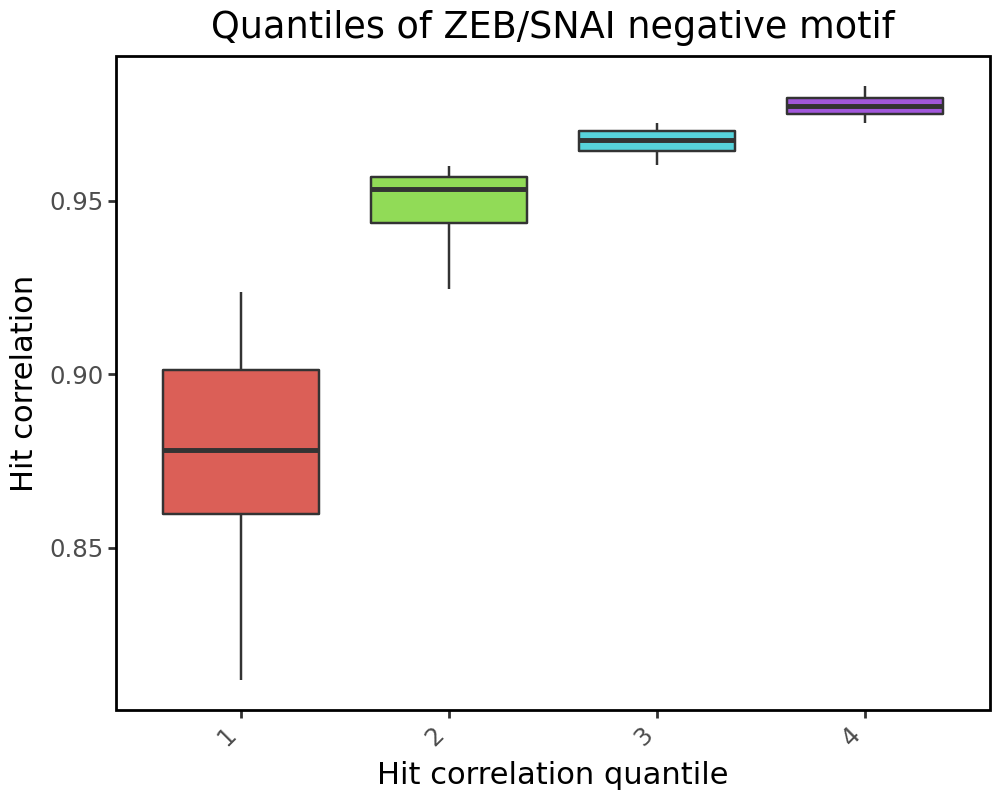

In [38]:
hits_zeb_q.head()

# check colnames
hits_zeb_q.columns

hits_zeb_q["quantile"] = np.repeat(np.arange(1, num_quantiles + 1), num_seqs_per_quantile)

p = (
	ggplot(hits_zeb_q, aes(x="factor(quantile)", y="hit_correlation"))
	+ geom_boxplot(aes(fill = "factor(quantile)"))
	+ xlab("Hit correlation quantile")
	+ ylab("Hit correlation")
	+ theme(legend_position = "none",
			panel_background = element_rect(fill = "white"),
			panel_border = element_rect(color = "black", fill = "white"),
			strip_background = element_blank(),
			figure_size = (5, 4),
			axis_text_x = element_text(angle = 45, hjust = 1)
			)
	+ ggtitle("Quantiles of ZEB/SNAI negative motif")
)

p

In [39]:
# sort by peak
hits_zeb_q = hits_zeb_q.sort_values("peak_id")
hits_zeb_q["peak_id"]

# get quantiles in peak order
quantiles_in_peak_order = hits_zeb_q["quantile"].values

5030          529
6462          670
10149        1041
11588        1174
13778        1377
            ...  
1884124    189906
1887285    190225
1888259    190326
1889507    190445
1890564    190545
Name: peak_id, Length: 1000, dtype: int64

In [40]:
# make a copy for sorting
hits_zeb_q2 = hits_zeb_q.copy().sort_values("hit_coefficient", ascending=True).reset_index(drop=True)
# rename seqnames column to chr
hits_zeb_q2 = hits_zeb_q2.rename(columns={"seqnames": "chr"})
hit_zeb_q_ohe = cutils.io.get_hits_seqs(hits_zeb_q2, hg38, revcomp=True, revcomp_strand='-')

@ output width: 15


In [41]:
hits_zeb_q2

,chr,start,end,width,strand,start_untrimmed,end_untrimmed,motif_name,source,hit_coefficient,...,pattern_class,distToGeneStart,nearestGene,peakType,distToTSS,nearestTSS,GC,N,distToPeakSummit,quantile
0,chr3,31980895,31980900,5,-,31980878,31980908,456|ZEB/SNAI,2,0.000125,...,neg_patterns,851,ZNF860,Promoter,47,ENST00000480671.5,0.4000,0,42,2
1,chr11,16857600,16857605,5,+,16857592,16857622,456|ZEB/SNAI,1,0.000171,...,neg_patterns,118011,SOX6,Intronic,1688,ENST00000637162.1,0.4000,0,229,2
2,chr6,26401810,26401815,5,-,26401793,26401823,456|ZEB/SNAI,2,0.000773,...,neg_patterns,423,BTN3A1,Promoter,423,ENST00000476549.6,0.4000,0,119,2
3,chr18,59546652,59546658,6,-,59546646,59546676,456|ZEB/SNAI,1,0.000860,...,neg_patterns,151006,CCBE1,Intronic,17053,ENST00000586841.1,0.5000,0,285,2
4,chr17,30376666,30376671,5,-,30376649,30376679,456|ZEB/SNAI,1,0.001785,...,neg_patterns,2257,CPD,Distal,2257,ENST00000225719.9,0.4000,0,316,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,chr10,80186882,80186887,5,-,80186865,80186895,456|ZEB/SNAI,2,27.312940,...,neg_patterns,18686,ANXA11,Intronic,13863,ENST00000437799.1,0.6000,0,38,4
996,chr3,59699815,59699821,6,-,59699809,59699839,456|ZEB/SNAI,2,28.861930,...,neg_patterns,649653,CFAP20DC-DT,Intronic,109450,ENST00000655190.1,0.6667,0,321,4
997,chr11,103682976,103682981,5,-,103682959,103682989,456|ZEB/SNAI,1,29.559778,...,neg_patterns,166926,MIR4693,Intronic,166926,ENST00000578405.1,0.6000,0,145,3
998,chr7,35259714,35259719,5,-,35259697,35259727,456|ZEB/SNAI,2,33.457474,...,neg_patterns,5616,TBX20,Distal,11,ENST00000442323.1,0.6000,0,1,3


This is for trimmed hits:

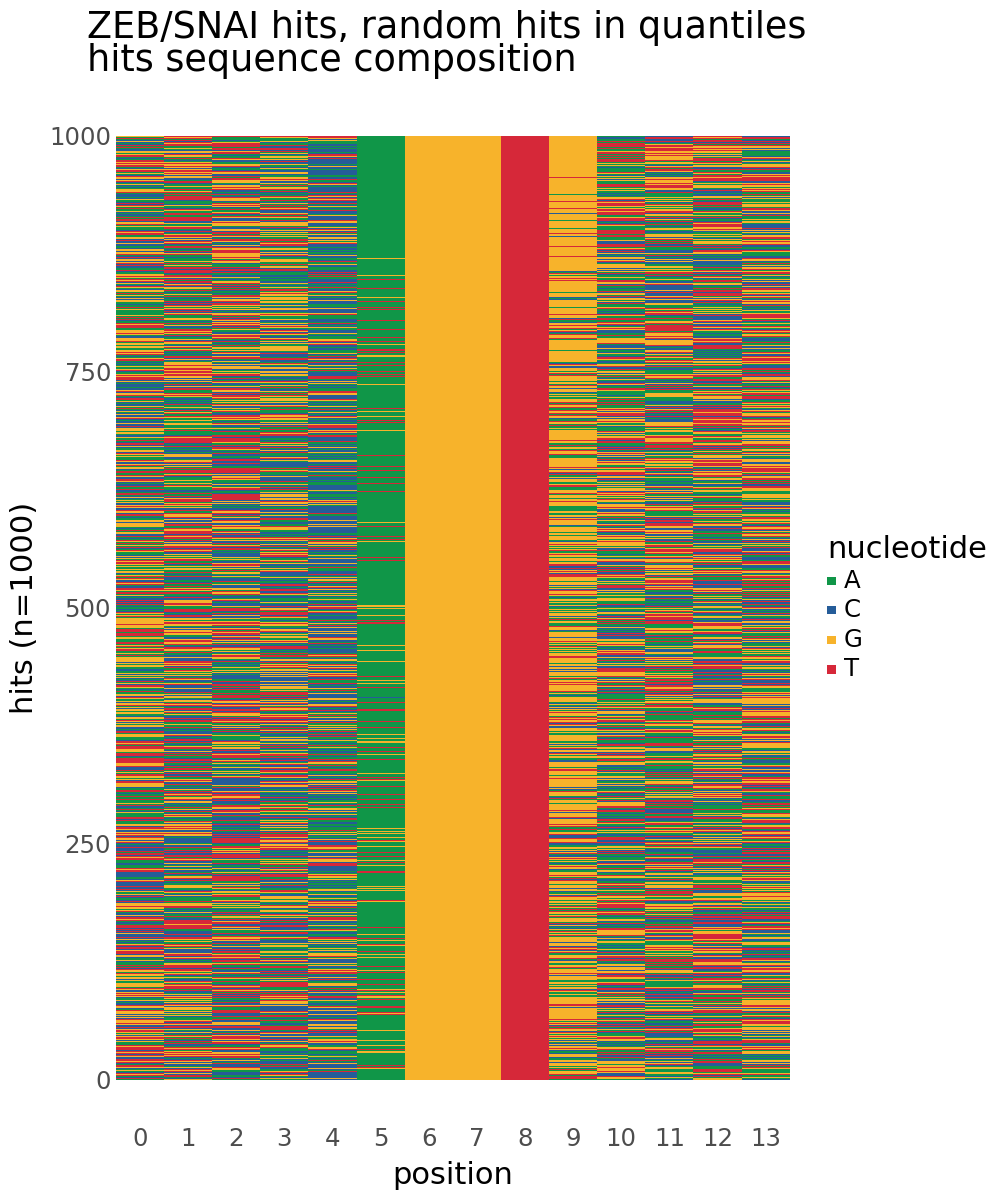

In [42]:
cutils.plot.hit_heatmap2(hit_zeb_q_ohe, "ZEB/SNAI hits, random hits in quantiles", figsize=(5,6), hit_order=hits_zeb_q2.index.values)

In [43]:
# colnames of hits
hits_zeb_q['peak_id']

hits_zeb_rel = get_rel_hit_positions(hits_zeb_q, X_peaks_coords)
hits_zeb_rel.keys()

5030          529
6462          670
10149        1041
11588        1174
13778        1377
            ...  
1884124    189906
1887285    190225
1888259    190326
1889507    190445
1890564    190545
Name: peak_id, Length: 1000, dtype: int64

(1000, 25)


dict_keys(['start_input', 'end_input', 'start_output', 'end_output'])

We can nicely see that the sequence below contains our motif:

In [44]:
sequence = hg38["chr1"][151585829:151585834].seq
sequence

'AGGTG'

In [45]:
peak_ids_sorted = hits_zeb_q['peak_id'].values

X_peaks_test = X_peaks[0][peak_ids_sorted]
X_peaks_test.shape

X_hyp_attr_test = torch.tensor(np.take(contribs_hyp, peak_ids_sorted, axis=0))
X_hyp_attr_test.shape

torch.Size([1000, 4, 2114])

torch.Size([1000, 4, 2114])

### Check out some contributions

In [46]:
plot_motif(np.float64(contribs_proj[peak_ids_sorted[0]][:, hits_zeb_rel['start_input'][0]-20:hits_zeb_rel['end_input'][0]+20]), type="CWM", title="Contributions", figsize=(10, 2))
plot_motif(np.float64(contribs_hyp[ peak_ids_sorted[0]][:, hits_zeb_rel['start_input'][0]-20:hits_zeb_rel['end_input'][0]+20]), type="CWM", title="Contributions", figsize=(10, 2))

Now by neutralizing those sequences, we should have sequences of the same shape:

In [47]:
X_neutral = replaceneutral(X_peaks_test, X_hyp_attr_test, starts=hits_zeb_rel['start_input'], ends=hits_zeb_rel['end_input'])
X_neutral.shape

torch.Size([1000, 4, 2114])

In [48]:
characters(X_peaks_test[0, :, hits_zeb_rel['start_input'][0]-20:hits_zeb_rel['end_input'][0]+20])
characters(X_neutral[0, :, hits_zeb_rel['start_input'][0]-20:hits_zeb_rel['end_input'][0]+20])

'GGCGCGGCGTGGGCTTCGCTCACCTGTCCCCGGCTGCCGCCCTCCG'

'GGCGCGGCGTGGGCTTCGCTTTTGGATCCCCGGCTGCCGCCCTCCG'

### Predictions

Predict accessibility at the original and neutralized sequences:

```python

In [49]:
y_before_list, y_after_list = [], []

for model in model_5f_chrombpnet:
	y_0 = tangermeme.predict.predict(model, X_peaks_test)
	y_before_list.append(y_0)

	y_1 = tangermeme.predict.predict(model, X_neutral)
	y_after_list.append(y_1)

y_before = reshape_folds(y_before_list)
y_after = reshape_folds(y_after_list)

Now we have predictions of shape (folds, sequences, 1, positions) for profile and (folds, sequences, 1) for counts.

In [50]:
y_before[0].shape
y_before[1].shape

y_before_counts_mean, _ = summarize_across_folds(y_before[1])
y_after_counts_mean, _ = summarize_across_folds(y_after[1])

y_before_counts_mean.shape
y_after_counts_mean.shape

y_before_profiles_mean, y_before_profiles_sd = summarize_across_folds(y_before[0])
y_after_profiles_mean, y_after_profiles_sd = summarize_across_folds(y_after[0])

y_before_profiles_mean.shape
y_after_profiles_mean.shape

torch.Size([5, 1000, 1, 1000])

torch.Size([5, 1000, 1])

torch.Size([1000, 1])

torch.Size([1000, 1])

torch.Size([1000, 1, 1000])

torch.Size([1000, 1, 1000])

Make a dataframe:

In [51]:
y_counts_means_df = pd.DataFrame({
	"peak_id": peak_ids_sorted,
	"quantile": quantiles_in_peak_order,
	"before": y_before_counts_mean.flatten(),
	"after": y_after_counts_mean.flatten(),
	"effect": y_after_counts_mean.flatten() - y_before_counts_mean.flatten()
})


# # Repeat quantile labels for each block of 50 sequences
# y_counts_means_df["quantile"] = np.repeat(np.arange(1, num_quantiles + 1), num_seqs_per_quantile)
y_counts_means_df.head

<bound method NDFrame.head of      peak_id  quantile    before     after    effect
0        529         3  7.735015  7.813213  0.078198
1        670         1  5.401598  5.475650  0.074052
2       1041         1  5.895226  5.981225  0.085999
3       1174         1  5.560222  5.576004  0.015782
4       1377         3  4.883883  4.949197  0.065313
..       ...       ...       ...       ...       ...
995   189906         3  4.078252  4.203252  0.125000
996   190225         4  4.899392  5.210462  0.311070
997   190326         1  5.126882  5.364223  0.237341
998   190445         1  5.555397  5.694695  0.139298
999   190545         2  4.594017  4.618619  0.024602

[1000 rows x 5 columns]>

We a small but systematic increase in the predicted accessibility at the regions.

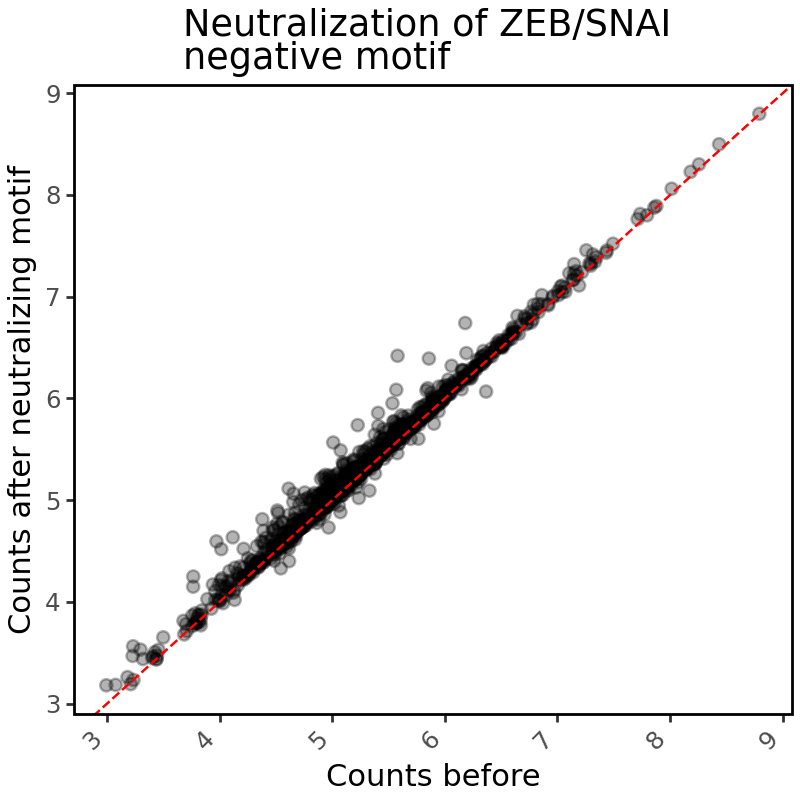

In [52]:
# Ensure quantile is categorical for color mapping
y_counts_means_df["quantile"] = y_counts_means_df["quantile"].astype(str)

p = (
	ggplot(y_counts_means_df, aes(x="before", y="after"))
	+ geom_point(alpha=0.3, size=2, shape='o', stroke=0.5)
	+ geom_abline(slope=1, intercept=0, color='red', linetype='dashed')
	+ xlab("Counts before")
	+ ylab("Counts after neutralizing motif")
	+ theme(legend_position = "none",
			panel_background = element_rect(fill = "white"),
			panel_border = element_rect(color = "black", fill = "white"),
			strip_background = element_blank(),
			figure_size = (4, 4),
			axis_text_x = element_text(angle = 45, hjust = 1)
			)
	+ ggtitle("Neutralization of ZEB/SNAI \nnegative motif")
)

p

We can also look at the effects per quantile of hits:

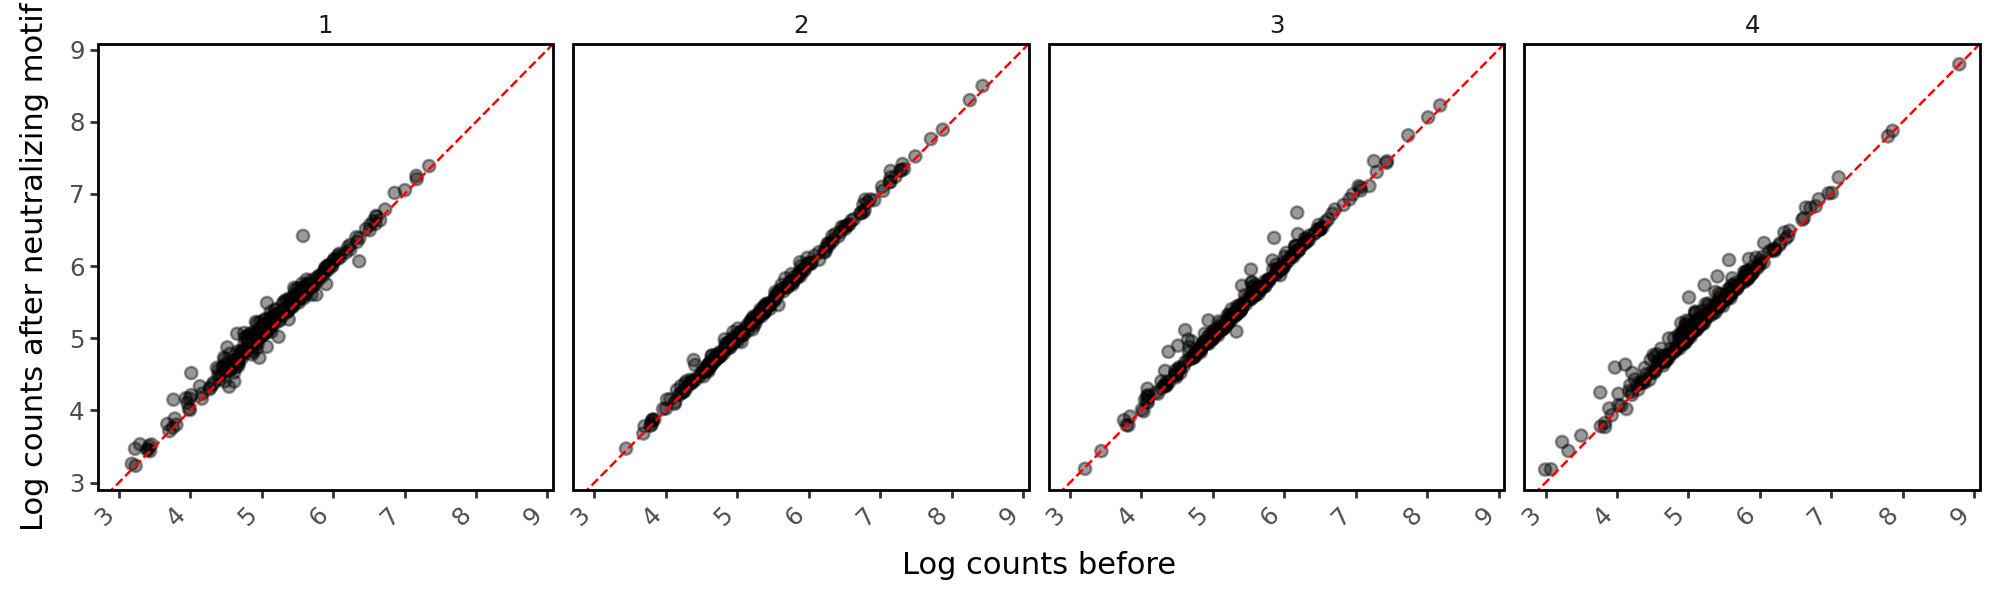

In [53]:
p = (

	ggplot(y_counts_means_df, aes(x="before", y="after"))
	+ geom_point(alpha=0.4, size=2, shape='o', stroke=0.5)
	+ geom_abline(slope=1, intercept=0, color='red', linetype='dashed')
	+ xlab("Log counts before")
	+ ylab("Log counts after neutralizing motif")
	+ facet_wrap("~quantile", ncol=5)
	+ theme(legend_position = "none",
			panel_background = element_rect(fill = "white"),
			panel_border = element_rect(color = "black", fill = "white"),
			strip_background = element_blank(),
			figure_size = (10, 3),
			axis_text_x = element_text(angle = 45, hjust = 1)
			)
)

p

Plot the effects directly:

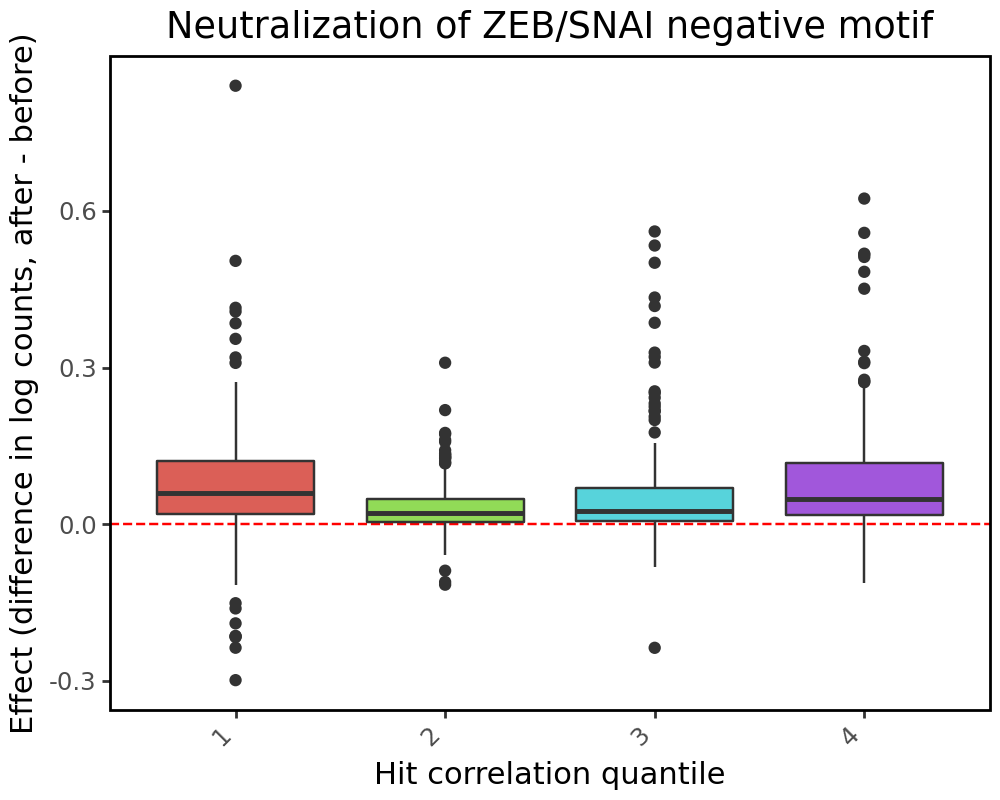

In [54]:
p = (
	ggplot(y_counts_means_df, aes(x="factor(quantile)", y="effect"))
	+ geom_hline(yintercept=0, color='red', linetype='dashed')
	+ geom_boxplot(aes(fill = "factor(quantile)"))
	+ xlab("Hit correlation quantile")
	+ ylab("Effect (difference in log counts, after - before)")
	+ theme(legend_position = "none",
			panel_background = element_rect(fill = "white"),
			panel_border = element_rect(color = "black", fill = "white"),
			strip_background = element_blank(),
			figure_size = (5, 4),
			axis_text_x = element_text(angle = 45, hjust = 1)
			)
	+ ggtitle("Neutralization of ZEB/SNAI negative motif")
)

p

Now we get the attributions before and after, let's just do a subset of sequences:

In [55]:
X_peaks_test.shape

torch.Size([1000, 4, 2114])

In [56]:
X_attr_before_list, X_attr_after_list = [], []

for model in model_5f_counts:

	# run deep lift shap
	attr_0 = deep_lift_shap(model, X_peaks_test[0:5, :, :].float(), random_state=0, batch_size=16)
	X_attr_before_list.append(attr_0)

	attr_1 = deep_lift_shap(model, X_neutral[0:5, :, :].float(), random_state=0, batch_size=16)
	X_attr_after_list.append(attr_1)

X_attr_before = torch.stack(X_attr_before_list, dim=0)
X_attr_after = torch.stack(X_attr_after_list, dim=0)

In [57]:
X_attr_before.shape
X_attr_after.shape

torch.Size([5, 5, 4, 2114])

torch.Size([5, 5, 4, 2114])

Let's look at the profiles:

In [58]:
hits_zeb_rel.keys()

dict_keys(['start_input', 'end_input', 'start_output', 'end_output'])

In [59]:
X_attr_before_mean, _ = summarize_across_folds(X_attr_before)
X_attr_after_mean, _ = summarize_across_folds(X_attr_after)

X_attr_before_mean.shape
X_attr_after_mean.shape

torch.Size([5, 4, 2114])

torch.Size([5, 4, 2114])

In [62]:
for i in range(5):

	fig, ax = plt.subplots(4, 1, figsize=(9, 6))

	ax[0].plot(y_before_profiles_mean[i, 0, :], linewidth=1, label="original", color='gray', alpha=0.6)
	ax[0].plot(y_after_profiles_mean[i, 0, :], linewidth=1, label="ZEB/SNAI neutralized", color='red', alpha=0.6)
	ax[0].axvspan(hits_zeb_rel['start_output'][i]-10, hits_zeb_rel['end_output'][i]+10, alpha=0.4, color='yellow')
	ax[0].legend(fontsize=8)
	ax[0].set_xlabel("Genomic position")
	ax[0].set_ylabel("Predicted profile")

	ax[1].plot(X_attr_before_mean[i].T.sum(axis=1), linewidth=1, label="original", color='gray', alpha=0.6)
	ax[1].plot(X_attr_after_mean[i].T.sum(axis=1), linewidth=1, label="ZEB/SNAI neutralized", color='blue', alpha=0.6)
	ax[1].axvspan(hits_zeb_rel['start_input'][i]-10, hits_zeb_rel['end_input'][i]+10, alpha=0.4, color='yellow')
	ax[1].legend(fontsize=8)
	ax[1].set_xlabel("Genomic position")
	ax[1].set_ylabel("Contribution scores")

	plot_motif(
		X_attr_before_mean[i, :, hits_zeb_rel['start_input'][i]-30:hits_zeb_rel['end_input'][i]+30].float().numpy().astype(np.float64),
		"Before", ax=ax[2]
	);
	plot_motif(
		X_attr_after_mean[i, :, hits_zeb_rel['start_input'][i]-30:hits_zeb_rel['end_input'][i]+30].float().numpy().astype(np.float64),
		"After", ax=ax[3]
	);

	ax[0].set_title("Prediction before and after ablating a ZEB/SNAI motif")

	plt.tight_layout()
	plt.show();


Text(0.5, 0, 'Genomic position')

Text(0, 0.5, 'Predicted profile')

Text(0.5, 0, 'Genomic position')

Text(0, 0.5, 'Contribution scores')

Text(0.5, 1.0, 'Prediction before and after ablating a ZEB/SNAI motif')

...

Text(0.5, 0, 'Genomic position')

Text(0, 0.5, 'Predicted profile')

Text(0.5, 0, 'Genomic position')

Text(0, 0.5, 'Contribution scores')

Text(0.5, 1.0, 'Prediction before and after ablating a ZEB/SNAI motif')

## Helper function

Now we create helper functions to run this for any motif.

In [63]:
from IPython.core.debugger import set_trace

def run_neutralize_motif(motif_name, hits_df, models, pattern_class, sort_by = "hit_correlation", n_quantiles = 4, n_seqs_per_quantile = 250, central_window = 500, debug = False):
	"""
	Args:
		motif_name (str): The name of the motif to neutralize.
		hits_df (pd.DataFrame): DataFrame containing hit information.
		models (list): List of 5-fold models to use for predictions.
		pattern_class (str): The class of the pattern to use.
		sort_by (str): Hit metric name to sort hits by.
		n_quantiles (int): Number of quantiles to create.
		n_seqs_per_quantile (int): Number of sequences to sample per quantile.
		debug (bool): Whether to run in debug mode.
	"""

	pattern = get_pattern_name(motif_name)

	# Get the motif ------------------------------------------------------------
	print("@ getting motif")
	# get the reverse-complement of the motif to match the orientation of the heterodimer
	# motif seen in the ChromBPNet paper
	cwm = modisco_obj[pattern_class][pattern]['contrib_scores'][()]
	trimmed_cwm, _, _ = trim_cwm(cwm)
	print("cwm", trimmed_cwm.shape)

	# Get hits -----------------------------------------------------------------
	print("@ subsetting hits")
	# look at a few hits which match the motif
	hits_subset = hits_df[hits_df["motif_name"] == motif_name]

	hits_subset = hits_subset.sort_values("peak_id")
	print("hits_subset", hits_subset.shape)

	# Subset to quantiles
	quantile_edges = np.linspace(0, 1, n_quantiles + 1)
	print("quantiles", quantile_edges)
	hits_quantiles = []

	for i in range(n_quantiles):
		q_low = hits_subset[sort_by].quantile(quantile_edges[i])
		q_high = hits_subset[sort_by].quantile(quantile_edges[i+1])
		if i == 0:
			mask = (hits_subset[sort_by] <= q_high)
		elif i == n_quantiles - 1:
			mask = (hits_subset[sort_by] > q_low)
		else:
			mask = (hits_subset[sort_by] > q_low) & (hits_subset[sort_by] <= q_high)
		hits_q = hits_subset[mask]
		hits_quantiles.append(hits_q.sample(n=min(n_seqs_per_quantile, len(hits_q)), random_state=6))

	# concatenate the hits
	hits_quantiles = pd.concat(hits_quantiles).sort_values("peak_id").reset_index(drop=True)
	hits_quantiles['quantile'] = np.repeat(np.arange(1, n_quantiles + 1), n_seqs_per_quantile)
	print("hits_quantiles", hits_quantiles.shape)

	hits_quantiles2 = hits_quantiles.copy().sort_values(sort_by, ascending=True).reset_index(drop=True)
	hits_quantiles2 = hits_quantiles2.rename(columns={"seqnames": "chr"})
	hits_quantiles_ohe = cutils.io.get_hits_seqs(hits_quantiles2, hg38, revcomp=True, revcomp_strand='-')
	quantiles_in_peak_order = hits_quantiles2['quantile'].values
	scores_in_peak_order = hits_quantiles2[sort_by].values

	# get relative hit positions
	hits_quantiles_rel = get_rel_hit_positions(hits_quantiles, X_peaks_coords)

	if debug:
		return hits_quantiles_ohe

	# Get peak regions and hypothetical contributions --------------------------
	print("@ getting peak regions and hypothetical contributions")
	peak_ids_sorted = hits_quantiles['peak_id'].values

	X_peaks_test = X_peaks[0][peak_ids_sorted]
	print("peaks", X_peaks_test.shape)

	# import pdb
	# pdb.set_trace()

	# np.take is used to select the rows corresponding to the peak_ids_sorted,
	# accounting for possible duplicate peak IDs in the hits.
	X_hyp_attr_test = torch.tensor(np.take(contribs_hyp, peak_ids_sorted, axis=0))
	print("hyp attributions", X_hyp_attr_test.shape)

	# Get observed insertion counts ------------------------------------------'
	print("@ getting observed insertions")
	obs_insertions = extract_accessibility(hits_quantiles2, obs_bw, central_window=central_window)

	# Neutralize region --------------------------------------------------------
	print("@ neutralizing region")
	X_neutral = replaceneutral(X_peaks_test, X_hyp_attr_test, starts=hits_quantiles_rel['start_input'], ends=hits_quantiles_rel['end_input'])
	print("peaks neutralized", X_neutral.shape)

	# Predictions --------------------------------------------------------------
	print("@ making predictions")
	y_before_list, y_after_list = [], []

	for model in models:
		y_0 = tangermeme.predict.predict(model, X_peaks_test)
		y_before_list.append(y_0)

		y_1 = tangermeme.predict.predict(model, X_neutral)
		y_after_list.append(y_1)

	y_before = reshape_folds(y_before_list)
	y_after = reshape_folds(y_after_list)

	y_before_counts_mean, _ = summarize_across_folds(y_before[1])
	y_after_counts_mean, _ = summarize_across_folds(y_after[1])

	print("counts before", y_before_counts_mean.shape)
	print("counts after", y_after_counts_mean.shape)

	y_before_profiles_mean, y_before_profiles_sd = summarize_across_folds(y_before[0])
	y_after_profiles_mean, y_after_profiles_sd = summarize_across_folds(y_after[0])

	y_counts_means_df = pd.DataFrame({
		"peak_id": peak_ids_sorted,
		"quantile": quantiles_in_peak_order,
		"score": scores_in_peak_order,
		"before": y_before_counts_mean.flatten(),
		"after": y_after_counts_mean.flatten(),
		"effect": y_after_counts_mean.flatten() - y_before_counts_mean.flatten()
	})

	# assign the quantile
	# Repeat quantile labels for each block of sequences
	y_counts_means_df["quantile"] = np.repeat(np.arange(1, n_quantiles + 1), n_seqs_per_quantile)
	y_counts_means_df.head

	preds = {
		'counts_df': y_counts_means_df,
		'counts_before_mean': y_before_counts_mean,
		'counts_after_mean': y_after_counts_mean,
		'profiles_before_mean': y_before_profiles_mean,
		'profiles_after_mean': y_after_profiles_mean,
		'profiles_before_sd': y_before_profiles_sd,
		'profiles_after_sd': y_after_profiles_sd
	}

	print("@ done.")

	return trimmed_cwm, hits_quantiles, hits_quantiles_ohe, X_peaks_test, X_neutral, obs_insertions, preds


In [64]:
def plot_neutralization_effect(counts_df, motif_name, n_quantiles = 4):

	p = (
		ggplot(counts_df, aes(x="before", y="after"))
		+ geom_point(alpha=0.3, size=2, shape='o', stroke=0.5)
		+ geom_abline(slope=1, intercept=0, color='red', linetype='dashed')
		+ xlab("Counts before")
		+ ylab("Counts after neutralizing motif")
		+ theme(
			legend_position="none",
			panel_background=element_rect(fill="white"),
			panel_border=element_rect(color="black", fill="white"),
			strip_background=element_blank(),
			figure_size=(4, 4),
			axis_text_x=element_text(angle=45, hjust=1)
		)
		+ ggtitle(f"{motif_name} \nmotif neutralization")
	)
	return p


def plot_score_boxplot(counts_df, motif_name):

	n_quantiles = counts_df['quantile'].nunique()

	# Generate n_colors shades of blue using seaborn
	blue_palette = seaborn.color_palette("Blues", n_colors=n_quantiles + 2)[2:]  # skip lightest
	blue_palette_hex = [to_hex(c) for c in blue_palette]

	p = (
		ggplot(counts_df, aes(x="factor(quantile)", y="score"))
		+ geom_boxplot(aes(fill="factor(quantile)"), outlier_shape="")
		+ geom_jitter(alpha=0.3, width=0.2, size=1)
		+ xlab("Hit score quantile")
		+ ylab("Hit score")
		# + ylim((-1, 1)) #
		+ scale_fill_manual(values=blue_palette_hex)
		+ theme(
			legend_position="none",
			panel_background=element_rect(fill="white"),
			panel_border=element_rect(color="black", fill="white"),
			strip_background=element_blank(),
			figure_size=(4, 4),
			axis_text_x=element_text(angle=45, hjust=1)
		)
		+ ggtitle(f"{motif_name} \nhit scores")
	)
	return p

def plot_neutralization_boxplot(counts_df, motif_name):

	n_quantiles = counts_df['quantile'].nunique()

	# Generate n_colors shades of blue using seaborn
	blue_palette = seaborn.color_palette("Blues", n_colors=n_quantiles + 2)[2:]  # skip lightest
	blue_palette_hex = [to_hex(c) for c in blue_palette]

	p = (
		ggplot(counts_df, aes(x="factor(quantile)", y="effect"))
		+ geom_hline(yintercept=0, color='red', linetype='dashed')
		+ geom_boxplot(aes(fill="factor(quantile)"), outlier_shape="")
		+ geom_jitter(alpha=0.3, width=0.2, size=1)
		+ xlab("Hit score quantile")
		+ ylab("Effect (difference in log counts, after - before)")
		# + ylim((-1, 1)) #
		+ scale_fill_manual(values=blue_palette_hex)
		+ theme(
			legend_position="none",
			panel_background=element_rect(fill="white"),
			panel_border=element_rect(color="black", fill="white"),
			strip_background=element_blank(),
			figure_size=(4, 4),
			axis_text_x=element_text(angle=45, hjust=1)
		)
		+ ggtitle(f"{motif_name} \nmotif neutralization")
	)
	return p

## CTCF

Start with CTCF as a sanity check.

In [65]:
motif_ctcf = "148|CTCF#1"
cwm0, hitsq0, hitsohe0, X0, Xneutral0, obs0, preds0 = run_neutralize_motif(motif_ctcf, hits_heart, model_5f_chrombpnet, "pos_patterns")

@ getting motif
cwm (14, 4)
@ subsetting hits
hits_subset (19101, 24)
quantiles [0.   0.25 0.5  0.75 1.  ]
hits_quantiles (1000, 25)
@ output width: 15
(1000, 25)
@ getting peak regions and hypothetical contributions
peaks torch.Size([1000, 4, 2114])
hyp attributions torch.Size([1000, 4, 2114])
@ getting observed insertions
@ neutralizing region
peaks neutralized torch.Size([1000, 4, 2114])
@ making predictions
counts before torch.Size([1000, 1])
counts after torch.Size([1000, 1])
@ done.


In [66]:
# save df
preds0['counts_df'].to_csv(os.path.join(out, "CTCF_neutralization_counts_df.tsv"), sep="\t", index=False)

In [67]:
plot_motif(cwm0.T, title = motif_ctcf, type="CWM")

Save as pdf:

In [68]:
# Create the plot
plot_motif(cwm0.T, title=motif_ctcf, type="CWM")

# Save the plot as a PDF
plt.savefig(os.path.join(figout, "motif_ctcf_plot.pdf"), format='pdf')

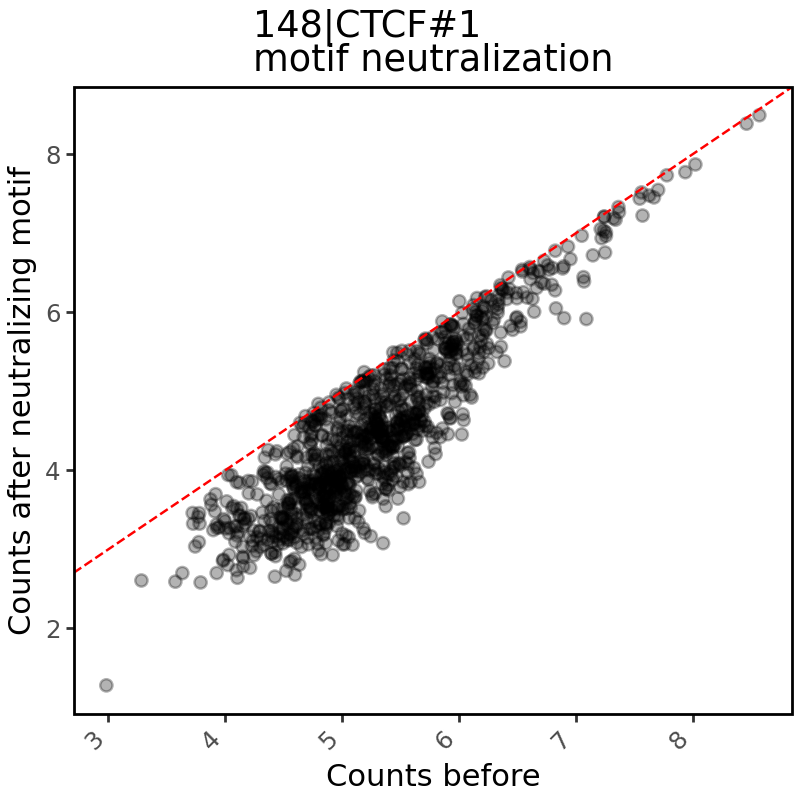

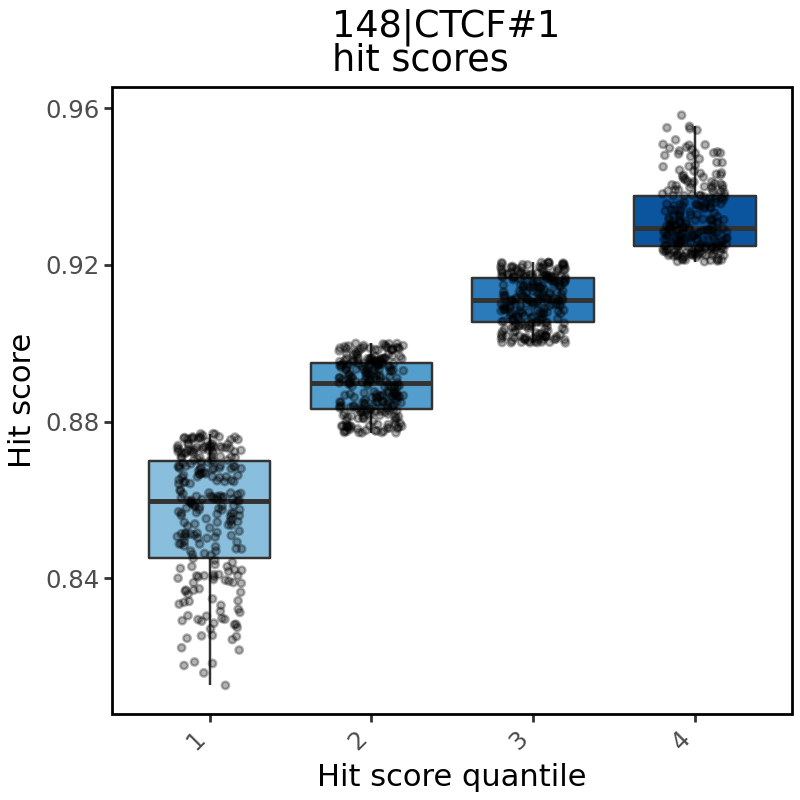

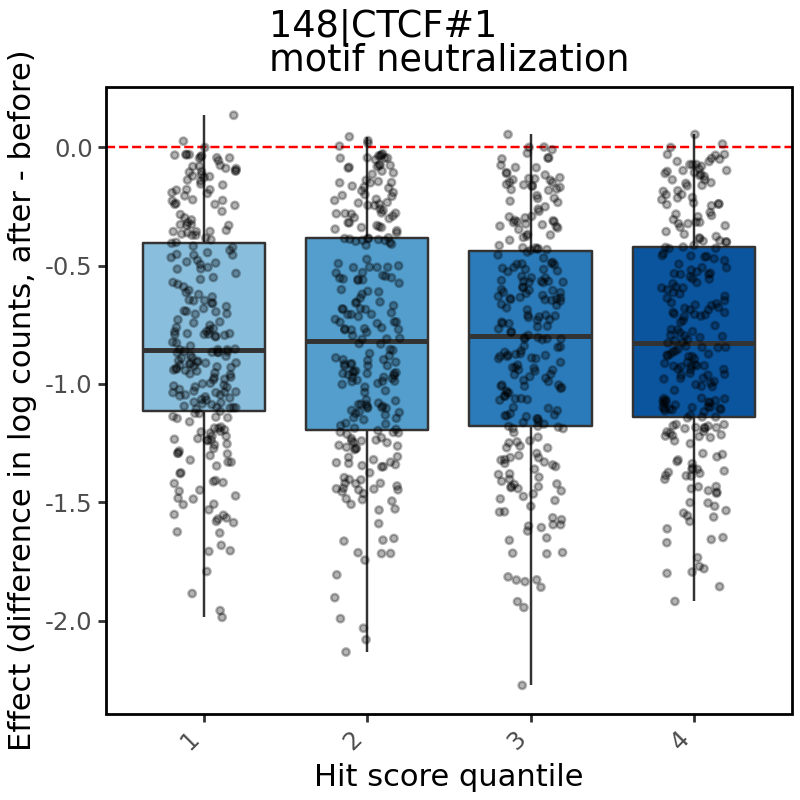

In [73]:
plot_neutralization_effect(preds0['counts_df'], motif_ctcf)
plot_score_boxplot(preds0['counts_df'], motif_ctcf)
plot_neutralization_boxplot(preds0['counts_df'], motif_ctcf)

## ZEB/SNAI

Here let's sort and quantile our hits by the importance, which as we saw above,
is the total absolute contribution score within the motif hit. This will allow us to see how the effect of neutralization changes with the strength of the motif hit.

In [74]:
cwm1, hitsq1, hitsohe1, X1, Xneutral1, obs1, preds1 = run_neutralize_motif(motif_zeb, hits_heart, model_5f_chrombpnet, "neg_patterns")

@ getting motif
cwm (5, 4)
@ subsetting hits
hits_subset (580664, 24)
quantiles [0.   0.25 0.5  0.75 1.  ]
hits_quantiles (1000, 25)
@ output width: 15
(1000, 25)
@ getting peak regions and hypothetical contributions
peaks torch.Size([1000, 4, 2114])
hyp attributions torch.Size([1000, 4, 2114])
@ getting observed insertions
@ neutralizing region
peaks neutralized torch.Size([1000, 4, 2114])
@ making predictions


counts before torch.Size([1000, 1])
counts after torch.Size([1000, 1])
@ done.


In [75]:
# save df
preds1['counts_df'].to_csv(os.path.join(out, "ZEB_neutralization_counts_df.tsv"), sep="\t", index=False)

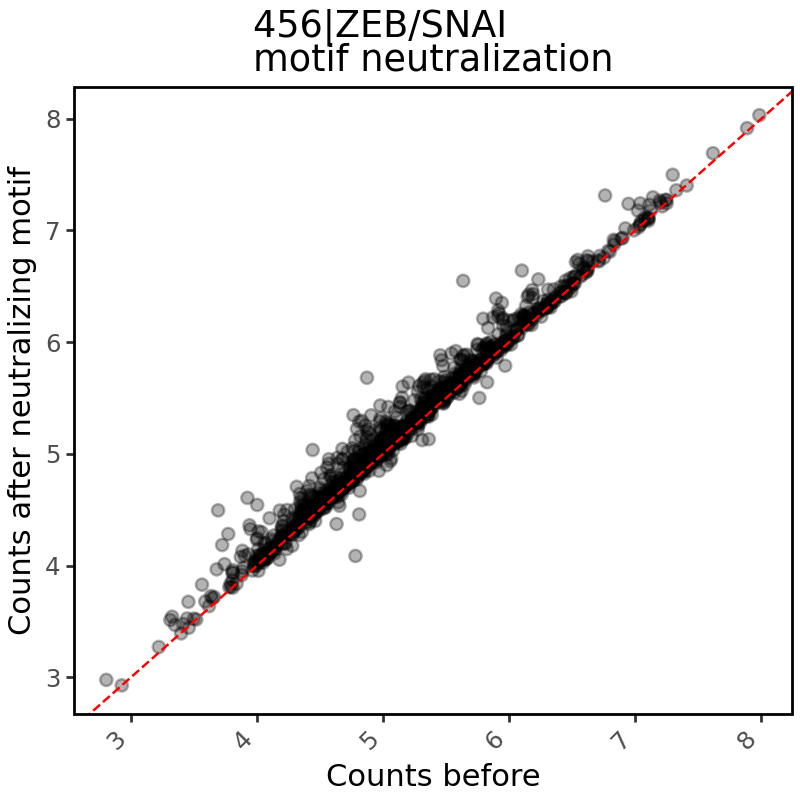

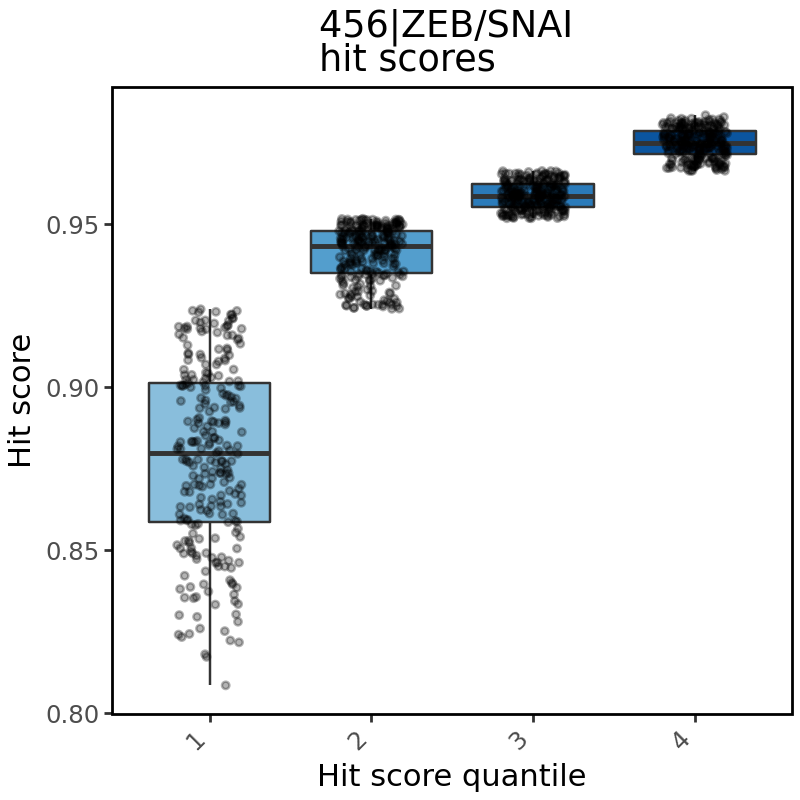

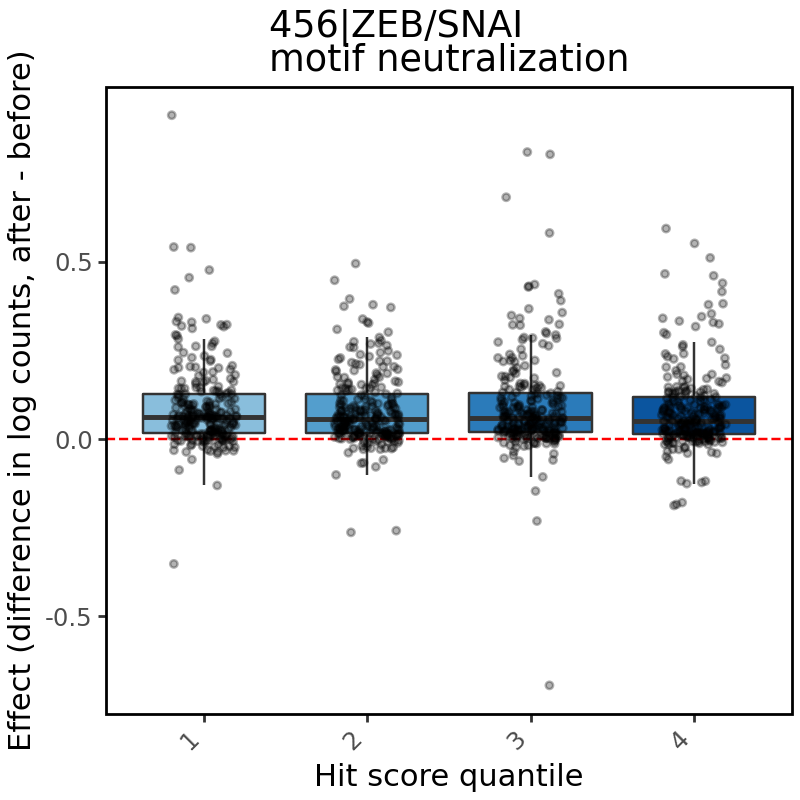

In [80]:
plot_neutralization_effect(preds1['counts_df'], motif_zeb)
plot_score_boxplot(preds1['counts_df'], motif_zeb)
plot_neutralization_boxplot(preds1['counts_df'], motif_zeb)

## NFY repressive

In [81]:
motif_nfy = "372|NFYrepressive"
cwm2, hitsq2, hitsohe2, X2, Xneutral2, obs2, preds2 = run_neutralize_motif(motif_nfy, hits_heart, model_5f_chrombpnet, "neg_patterns")

@ getting motif
cwm (12, 4)
@ subsetting hits
hits_subset (4388, 24)
quantiles [0.   0.25 0.5  0.75 1.  ]
hits_quantiles (1000, 25)
@ output width: 15
(1000, 25)
@ getting peak regions and hypothetical contributions
peaks torch.Size([1000, 4, 2114])
hyp attributions torch.Size([1000, 4, 2114])
@ getting observed insertions
@ neutralizing region
peaks neutralized torch.Size([1000, 4, 2114])
@ making predictions
counts before torch.Size([1000, 1])
counts after torch.Size([1000, 1])
@ done.


In [82]:
# save df
preds2['counts_df'].to_csv(os.path.join(out, "NFYneg_neutralization_counts_df.tsv"), sep="\t", index=False)

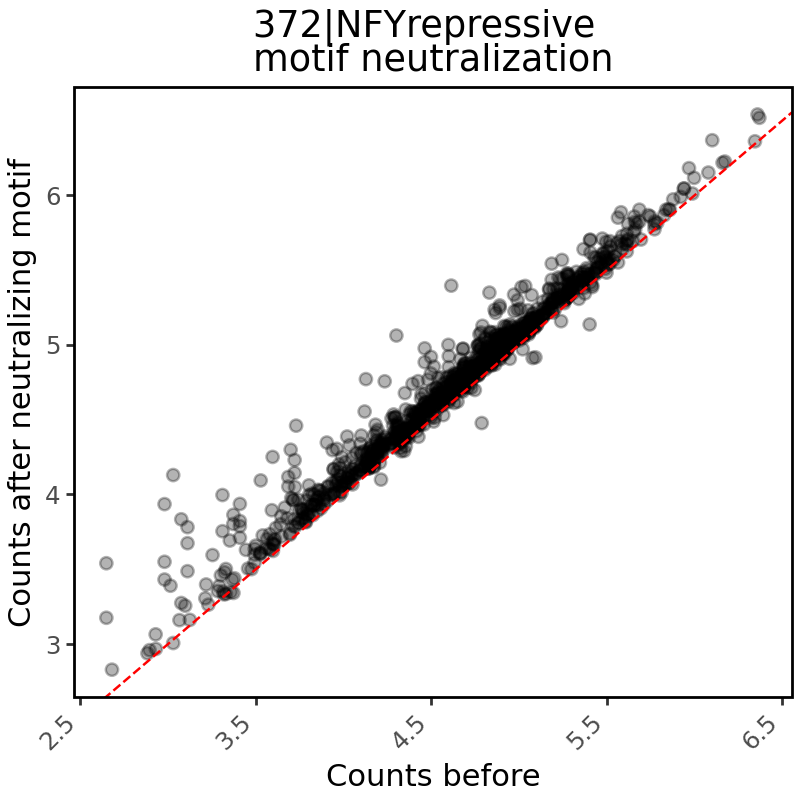

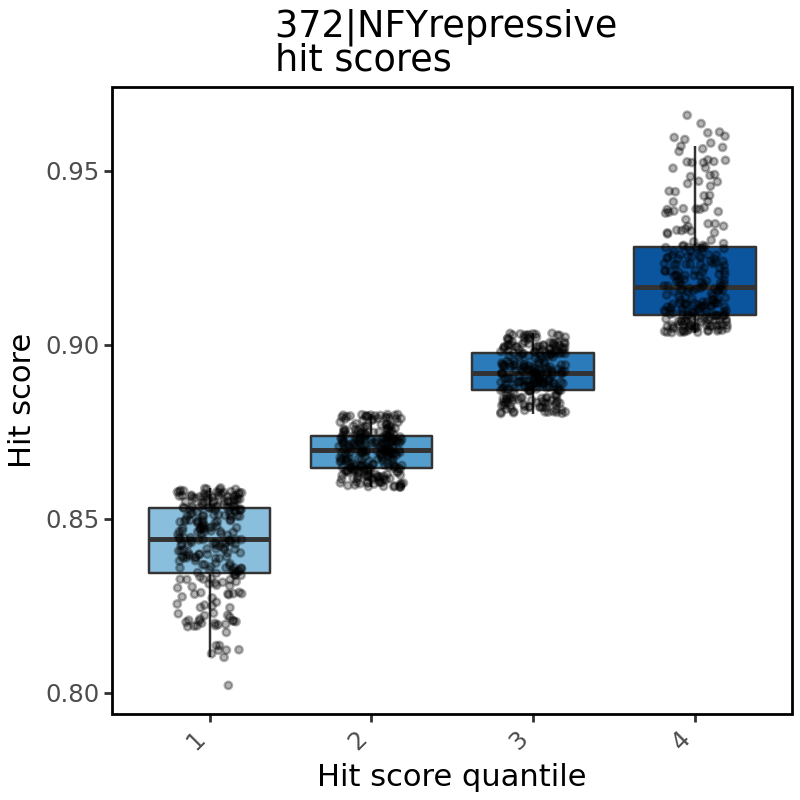

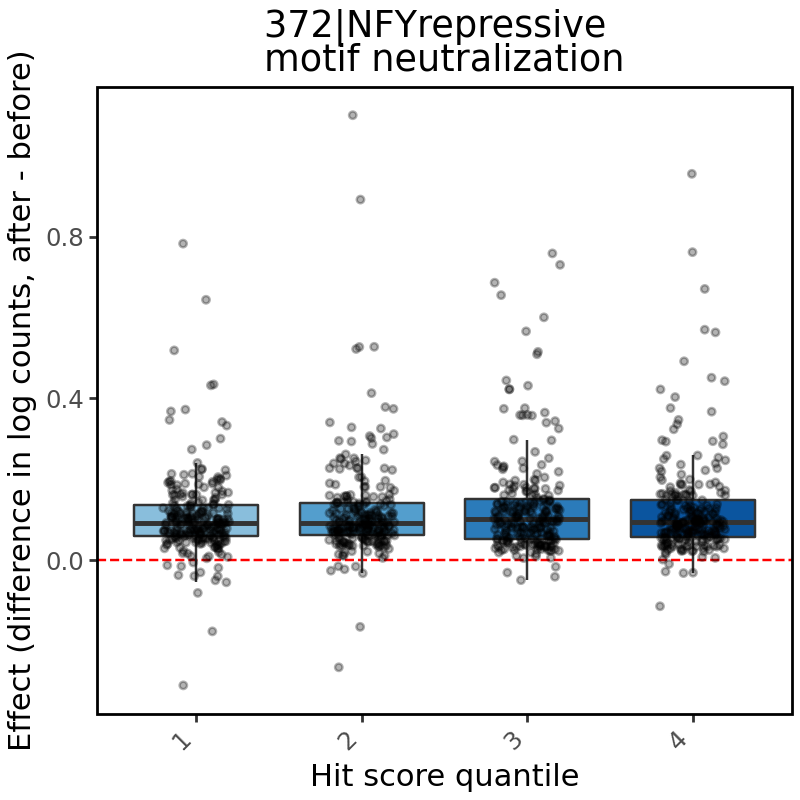

In [87]:
plot_neutralization_effect(preds2['counts_df'], motif_nfy)
plot_score_boxplot(preds2['counts_df'], motif_nfy)
plot_neutralization_boxplot(preds2['counts_df'], motif_nfy)

## YY1 repressive

In [88]:
motif_yy1 = "455|YY1/2repressive"
cwm3, hitsq3, hitsohe3, X3, Xneutral3, obs3, preds3 = run_neutralize_motif(motif_yy1, hits_heart, model_5f_chrombpnet, "neg_patterns")

@ getting motif
cwm (8, 4)
@ subsetting hits
hits_subset (1568, 24)
quantiles [0.   0.25 0.5  0.75 1.  ]
hits_quantiles (1000, 25)
@ output width: 15
(1000, 25)
@ getting peak regions and hypothetical contributions
peaks torch.Size([1000, 4, 2114])
hyp attributions torch.Size([1000, 4, 2114])
@ getting observed insertions
@ neutralizing region
peaks neutralized torch.Size([1000, 4, 2114])
@ making predictions


counts before torch.Size([1000, 1])
counts after torch.Size([1000, 1])
@ done.


In [89]:
# save df
preds3['counts_df'].to_csv(os.path.join(out, "YY1neg_neutralization_counts_df.tsv"), sep="\t", index=False)

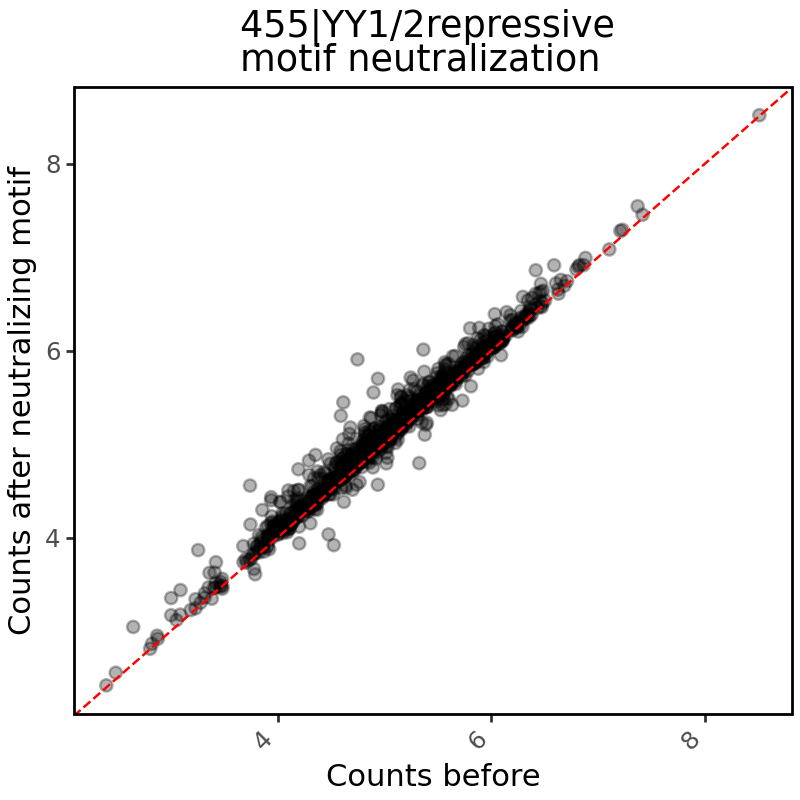

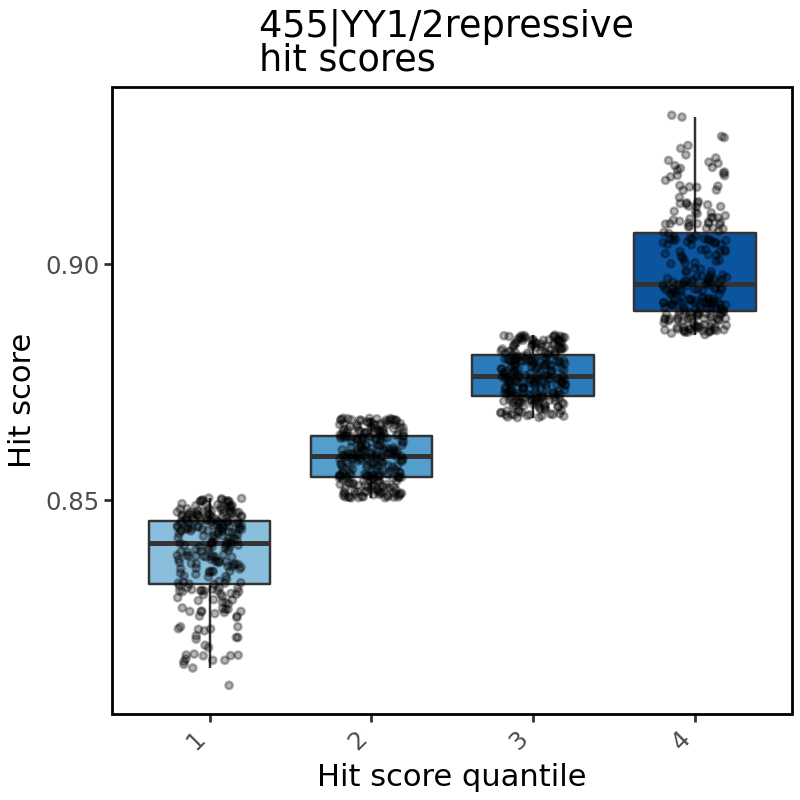

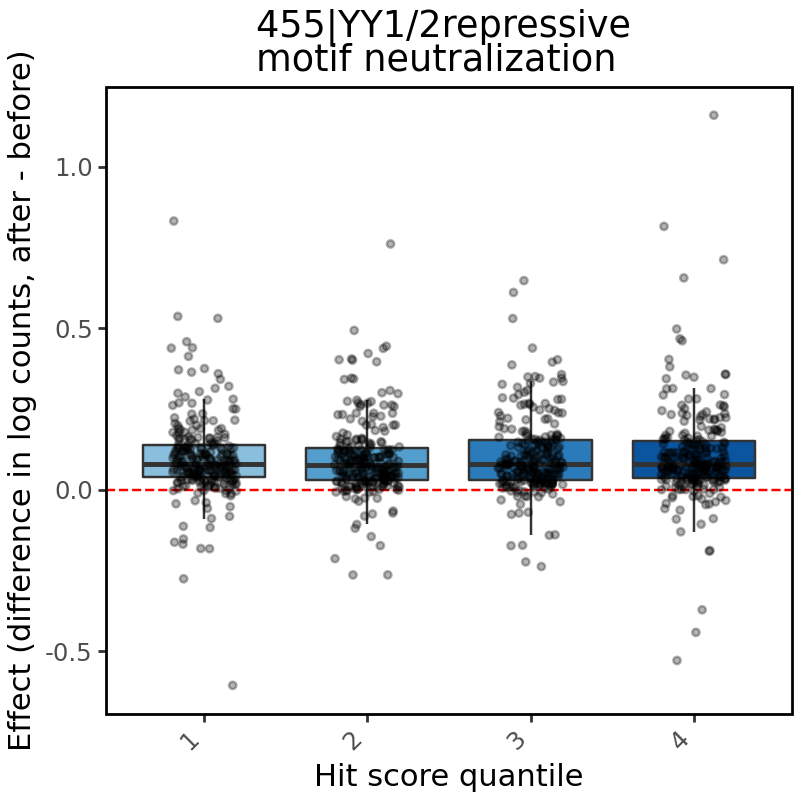

In [95]:
plot_neutralization_effect(preds3['counts_df'], motif_yy1)
plot_score_boxplot(preds3['counts_df'], motif_yy1)
plot_neutralization_boxplot(preds3['counts_df'], motif_yy1)

## NFY positive

In [96]:
motif_nfypos = "367|NFY"
cwm4, hitsq4, hitsohe4, X4, Xneutral4, obs4, preds4 = run_neutralize_motif(motif_nfypos, hits_heart, model_5f_chrombpnet, "pos_patterns")

@ getting motif
cwm (7, 4)
@ subsetting hits
hits_subset (16653, 24)
quantiles [0.   0.25 0.5  0.75 1.  ]
hits_quantiles (1000, 25)
@ output width: 15
(1000, 25)
@ getting peak regions and hypothetical contributions
peaks torch.Size([1000, 4, 2114])
hyp attributions torch.Size([1000, 4, 2114])
@ getting observed insertions
@ neutralizing region
peaks neutralized torch.Size([1000, 4, 2114])
@ making predictions
counts before torch.Size([1000, 1])
counts after torch.Size([1000, 1])
@ done.


In [97]:
# save df
preds4['counts_df'].to_csv(os.path.join(out, "NFYpos_neutralization_counts_df.tsv"), sep="\t", index=False)

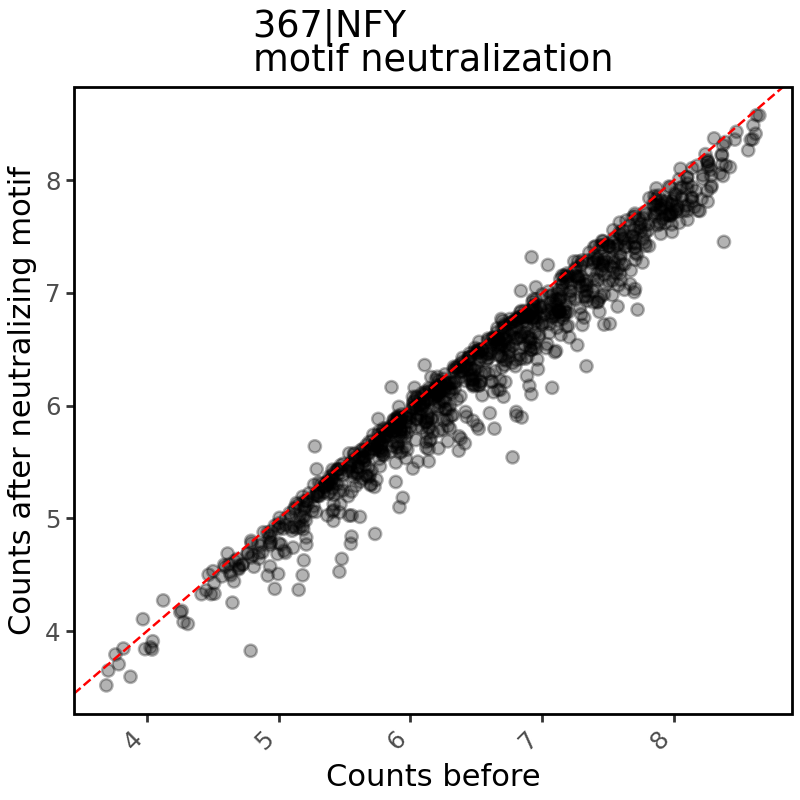

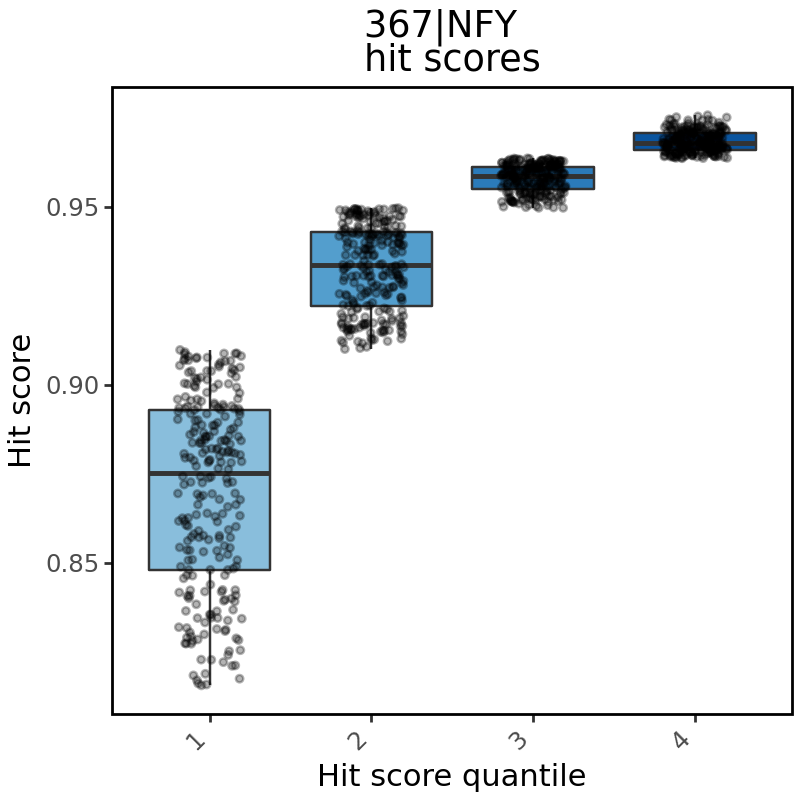

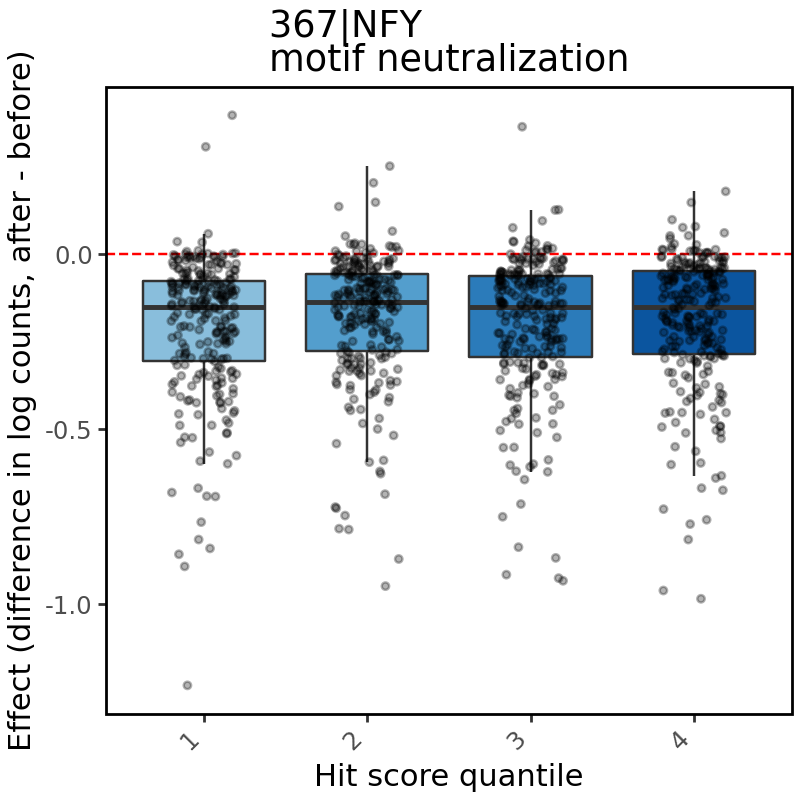

In [102]:
plot_neutralization_effect(preds4['counts_df'], motif_nfypos)
plot_score_boxplot(preds4['counts_df'], motif_nfypos)
plot_neutralization_boxplot(preds4['counts_df'], motif_nfypos)

## YY1 positive

In [103]:
motif_yy1pos = "454|YY1/2"
cwm5, hitsq5, hitsohe5, X5, Xneutral5, obs5, preds5 = run_neutralize_motif(motif_yy1pos, hits_heart, model_5f_chrombpnet, "pos_patterns")

@ getting motif
cwm (11, 4)
@ subsetting hits
hits_subset (3686, 24)
quantiles [0.   0.25 0.5  0.75 1.  ]
hits_quantiles (1000, 25)
@ output width: 15
(1000, 25)
@ getting peak regions and hypothetical contributions
peaks torch.Size([1000, 4, 2114])
hyp attributions torch.Size([1000, 4, 2114])
@ getting observed insertions
@ neutralizing region
peaks neutralized torch.Size([1000, 4, 2114])
@ making predictions
counts before torch.Size([1000, 1])
counts after torch.Size([1000, 1])
@ done.


In [104]:
# save df
preds5['counts_df'].to_csv(os.path.join(out, "YY1pos_neutralization_counts_df.tsv"), sep="\t", index=False)

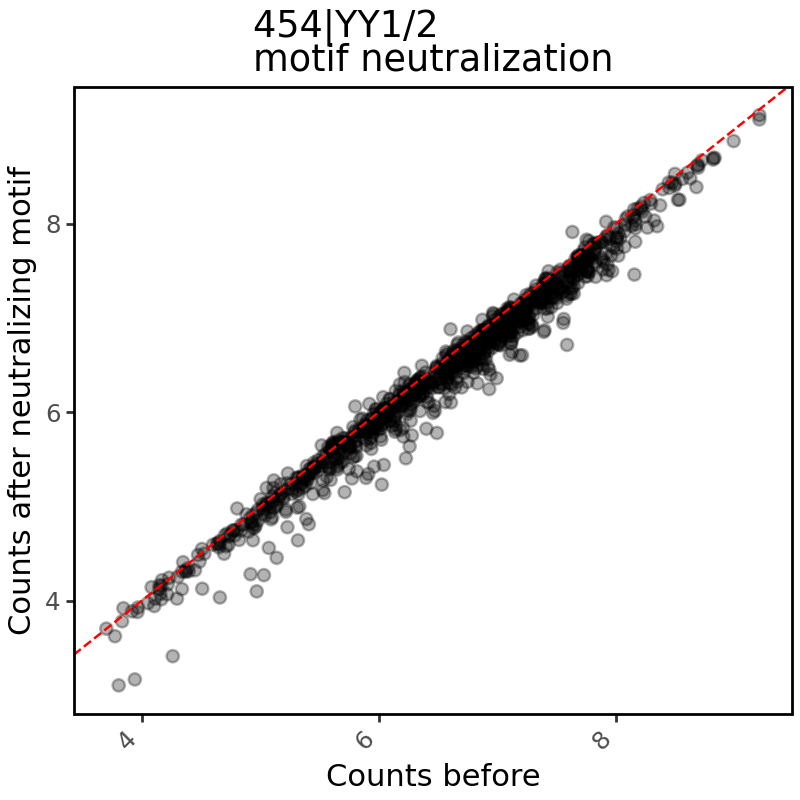

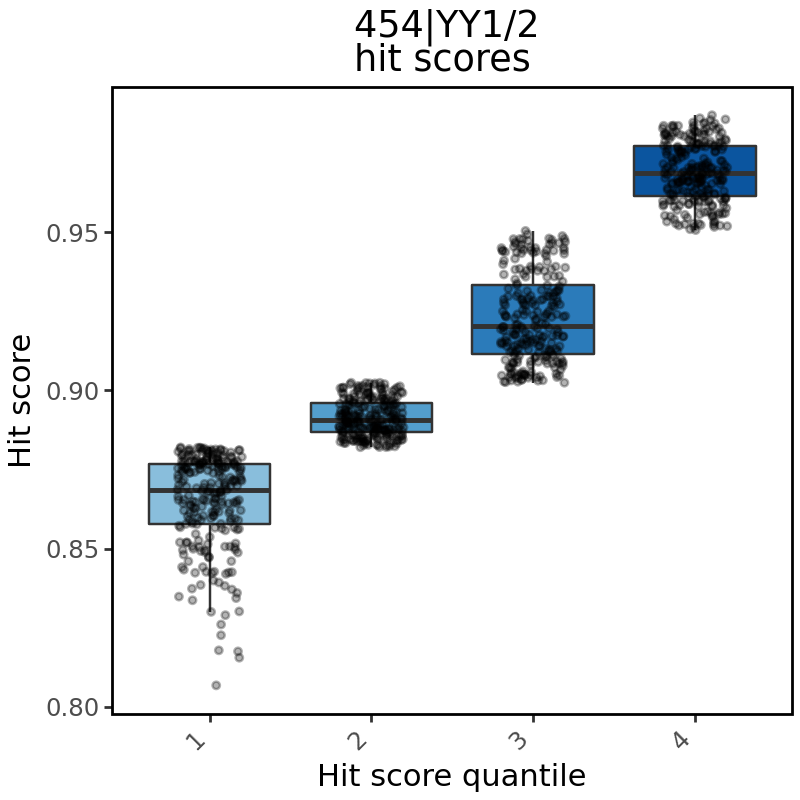

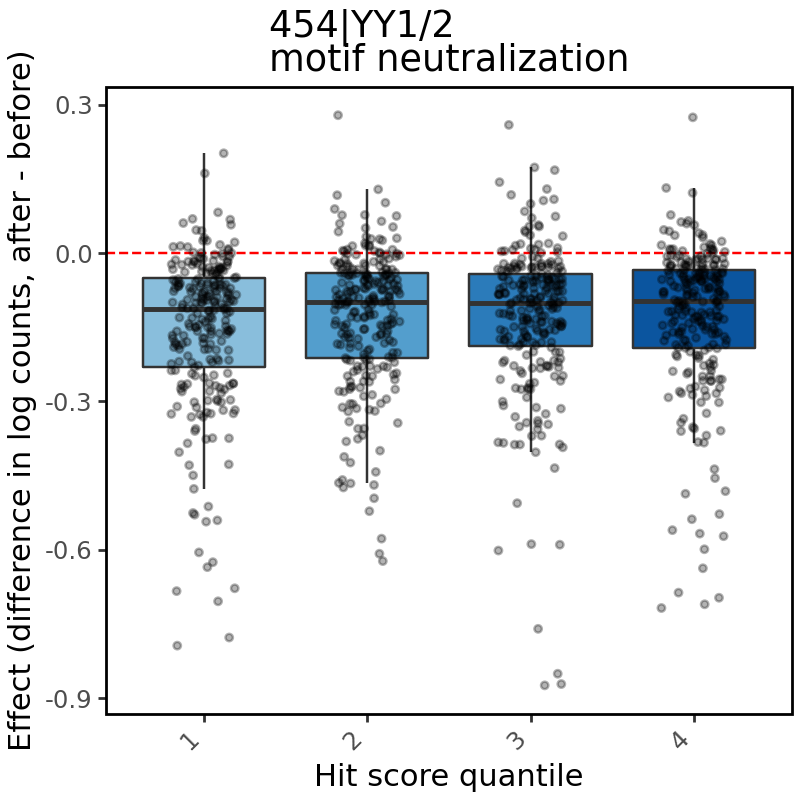

In [109]:
plot_neutralization_effect(preds5['counts_df'], motif_yy1pos)
plot_score_boxplot(preds5['counts_df'], motif_yy1pos)
plot_neutralization_boxplot(preds5['counts_df'], motif_yy1pos)

## HIC negative

In [110]:
motif_hic = "333|HIC"
cwm6, hitsq6, hitsohe6, X6, Xneutral6, obs6, preds6 = run_neutralize_motif(motif_hic, hits_heart, model_5f_chrombpnet, "neg_patterns")

@ getting motif
cwm (5, 4)
@ subsetting hits
hits_subset (222904, 24)
quantiles [0.   0.25 0.5  0.75 1.  ]
hits_quantiles (1000, 25)
@ output width: 15
(1000, 25)
@ getting peak regions and hypothetical contributions
peaks torch.Size([1000, 4, 2114])
hyp attributions torch.Size([1000, 4, 2114])
@ getting observed insertions
@ neutralizing region
peaks neutralized torch.Size([1000, 4, 2114])
@ making predictions


counts before torch.Size([1000, 1])
counts after torch.Size([1000, 1])
@ done.


In [111]:
# save df
preds6['counts_df'].to_csv(os.path.join(out, "HIC_neutralization_counts_df.tsv"), sep="\t", index=False)

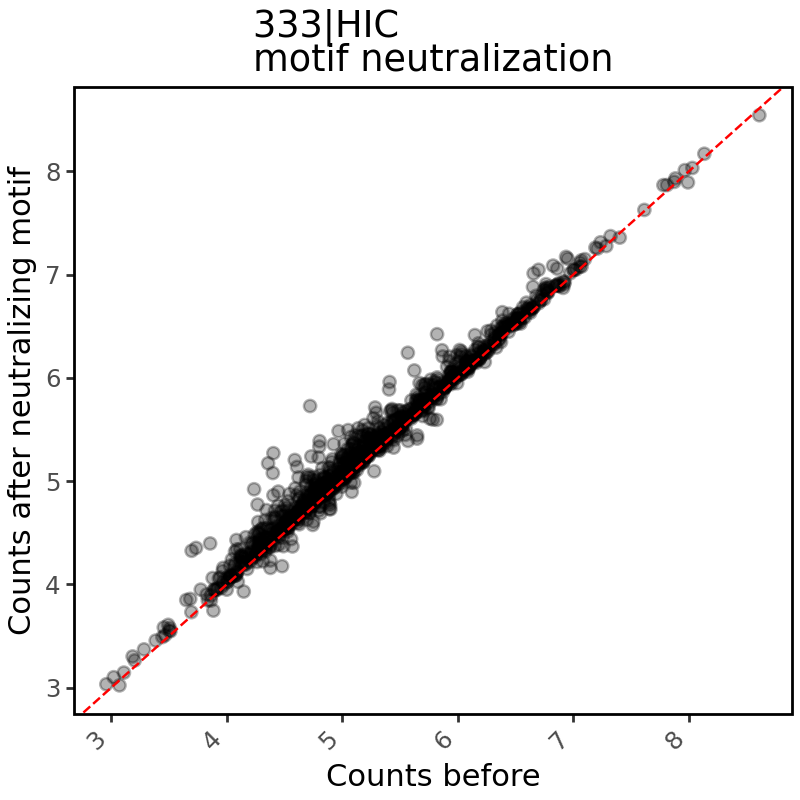

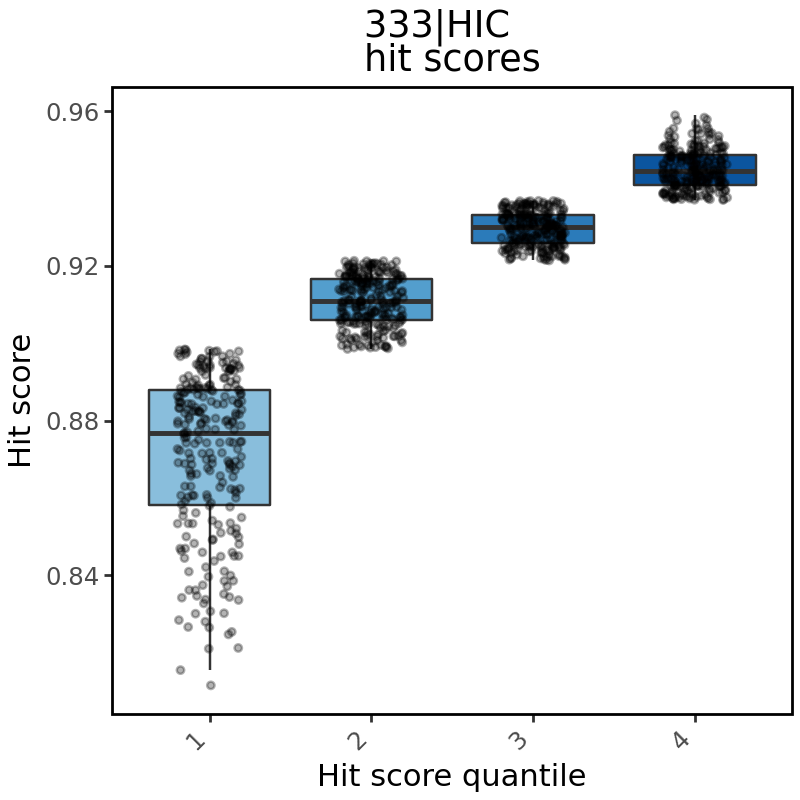

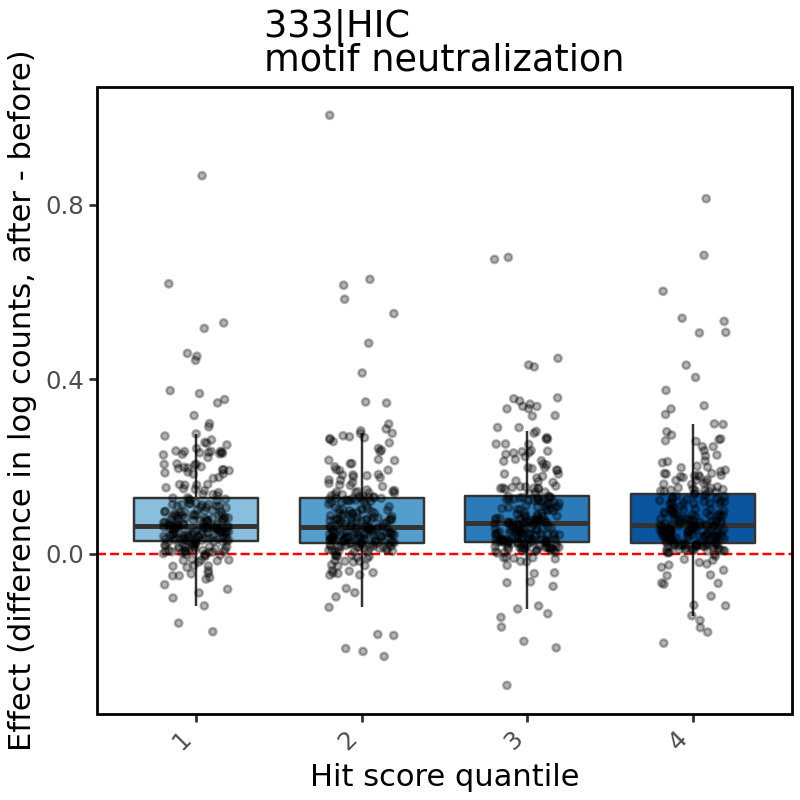

In [116]:
plot_neutralization_effect(preds6['counts_df'], motif_hic)
plot_score_boxplot(preds6['counts_df'], motif_hic)
plot_neutralization_boxplot(preds6['counts_df'], motif_hic)

# Plot all results

In [117]:
motifs = ["CTCF", "ZEB", "NFYneg", "YY1neg", "NFYpos", "YY1pos", "HIC"]
out_paths = [os.path.join(out, f"{m}_neutralization_counts_df.tsv") for m in motifs]
ablation_df = pd.concat([pd.read_csv(p, sep="\t").assign(motif=m) for p, m in zip(out_paths, motifs) if os.path.exists(p)], axis=0)
ablation_df['quantile'] = ablation_df['quantile'].astype('category')

ablation_df.head()

,peak_id,quantile,score,before,after,effect,motif
0,35,1,0.812728,6.024004,4.452874,-1.571129,CTCF
1,150,1,0.815907,7.778663,7.733013,-0.045650,CTCF
2,179,1,0.817796,5.943585,5.826977,-0.116608,CTCF
3,261,1,0.818313,5.846359,5.745292,-0.101067,CTCF
4,292,1,0.818696,5.891437,5.534496,-0.356941,CTCF


In [118]:
# count points
ablation_df.groupby('motif').size()

motif
CTCF      1000
HIC       1000
NFYneg    1000
NFYpos    1000
YY1neg    1000
YY1pos    1000
ZEB       1000
dtype: int64

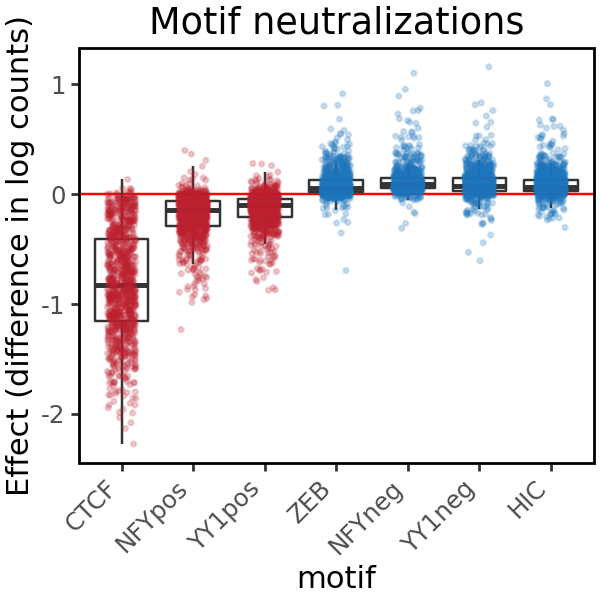

/oak/stanford/groups/akundaje/sjessa/software/miniconda3/envs/tangermeme/lib/python3.12/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 3 x 3 in image.
/oak/stanford/groups/akundaje/sjessa/software/miniconda3/envs/tangermeme/lib/python3.12/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /oak/stanford/groups/wjg/skim/projects/HDMA-public/figures/03-chrombpnet/03-syntax/09/motif_neutralization_effects.pdf


In [119]:
# assign motif order
ablation_df['motif'] = pd.Categorical(ablation_df['motif'],
    categories=['CTCF', 'NFYpos', 'YY1pos', 'ZEB', 'NFYneg', 'YY1neg', 'HIC'],
    ordered=True)

# set the pattern class as positive or negative
ablation_df['pattern_class'] = np.where(ablation_df['motif'].isin(['CTCF', 'NFYpos', 'YY1pos']), 'positive', 'negative')

p = (
  ggplot(ablation_df, aes(x='motif', y='effect'))
    + geom_hline(yintercept=0, color="red")
    + geom_boxplot(fill = "white", outlier_shape="")
    + geom_jitter(aes(color = 'pattern_class'), size = 0.5, width = 0.2, alpha = 0.2)
    + scale_color_manual(values={"positive": "#BD202E", "negative": "#1D75BC"})
    # + coord_cartesian(ylim=(-1, 1))
    + ylab("Effect (difference in log counts)")
    + ggtitle("Motif neutralizations")
    + theme(
			legend_position="none",
			panel_background=element_rect(fill="white"),
			panel_border=element_rect(color="black", fill="white"),
			strip_background=element_blank(),
			figure_size=(3, 3),
			axis_text_x=element_text(angle=45, hjust=1)
		)
)

p

# save figure
p.save(os.path.join(figout, "motif_neutralization_effects.pdf"))